# Analyse des prix de l'électricité franco-allemands en 2025

Sommaire
- Nettoyage et description
- Analyse en séries temporelles
- Analyse par la théorie des extrêmes
- Analyse en copules
- Analyse par processus de Hawkes

## Nettoyage et description

In [2]:
# Imports

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)

In [3]:
# Locate and load all 2025 monthly files
data_dir = Path("./files/")
files = sorted(data_dir.glob("2025_*_EnergyPrices_12.1.D_r3.csv"))

assert len(files) == 12, f"Expected 12 files, found {len(files)}"

dfs = []
for f in files:
    df = pd.read_csv(f, sep="\t")
    df["source_file"] = f.name
    dfs.append(df)

raw = pd.concat(dfs, ignore_index=True)

print("Shape:", raw.shape)
print("Files:", [f.name for f in files[:3]], "...", files[-1].name)
raw.head()

Shape: (1061543, 13)
Files: ['2025_01_EnergyPrices_12.1.D_r3.csv', '2025_02_EnergyPrices_12.1.D_r3.csv', '2025_03_EnergyPrices_12.1.D_r3.csv'] ... 2025_12_EnergyPrices_12.1.D_r3.csv


,InstanceCode,DateTime(UTC),ResolutionCode,AreaCode,AreaDisplayName,AreaTypeCode,MapCode,ContractType,Sequence,Price[Currency/MWh],Currency,UpdateTime(UTC),source_file
0,a860e32b38ca1e715f0e09da00bb337b,2025-01-01 00:00:00,PT60M,10YAT-APG------L,Austria (AT),BZN,AT,Day-ahead,1,97.03,EUR,2024-12-31 12:31:39,2025_01_EnergyPrices_12.1.D_r3.csv
1,a860e32b38ca1e715f0e09da00bb337b,2025-01-01 01:00:00,PT60M,10YAT-APG------L,Austria (AT),BZN,AT,Day-ahead,1,91.47,EUR,2024-12-31 12:31:39,2025_01_EnergyPrices_12.1.D_r3.csv
2,a860e32b38ca1e715f0e09da00bb337b,2025-01-01 02:00:00,PT60M,10YAT-APG------L,Austria (AT),BZN,AT,Day-ahead,1,72.87,EUR,2024-12-31 12:31:39,2025_01_EnergyPrices_12.1.D_r3.csv
3,a860e32b38ca1e715f0e09da00bb337b,2025-01-01 03:00:00,PT60M,10YAT-APG------L,Austria (AT),BZN,AT,Day-ahead,1,77.42,EUR,2024-12-31 12:31:39,2025_01_EnergyPrices_12.1.D_r3.csv
4,a860e32b38ca1e715f0e09da00bb337b,2025-01-01 04:00:00,PT60M,10YAT-APG------L,Austria (AT),BZN,AT,Day-ahead,1,95.01,EUR,2024-12-31 12:31:39,2025_01_EnergyPrices_12.1.D_r3.csv


In [4]:
# Quick schema inspection
raw.info()
raw.nunique().sort_values(ascending=False).head(20)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1061543 entries, 0 to 1061542
Data columns (total 13 columns):
 #   Column               Non-Null Count    Dtype  
---  ------               --------------    -----  
 0   InstanceCode         1061543 non-null  object 
 1   DateTime(UTC)        1061543 non-null  object 
 2   ResolutionCode       1061543 non-null  object 
 3   AreaCode             1061543 non-null  object 
 4   AreaDisplayName      1061543 non-null  object 
 5   AreaTypeCode         1061543 non-null  object 
 6   MapCode              1061543 non-null  object 
 7   ContractType         1061543 non-null  object 
 8   Sequence             1061543 non-null  object 
 9   Price[Currency/MWh]  1061543 non-null  float64
 10  Currency             1061543 non-null  object 
 11  UpdateTime(UTC)      1061543 non-null  object 
 12  source_file          1061543 non-null  object 
dtypes: float64(1), object(12)
memory usage: 105.3+ MB


DateTime(UTC)          35040
Price[Currency/MWh]    32929
InstanceCode           18329
UpdateTime(UTC)        14104
AreaCode                  47
MapCode                   47
AreaDisplayName           47
source_file               12
Sequence                   4
ResolutionCode             2
ContractType               2
Currency                   2
AreaTypeCode               1
dtype: int64

In [5]:
# Standardize dtypes and names
df = raw.copy()

df["DateTime(UTC)"] = pd.to_datetime(df["DateTime(UTC)"], utc=True, errors="coerce")
df["UpdateTime(UTC)"] = pd.to_datetime(df["UpdateTime(UTC)"], utc=True, errors="coerce")
df["Price[Currency/MWh]"] = pd.to_numeric(df["Price[Currency/MWh]"], errors="coerce")

# Optional: cleaner column names
df = df.rename(columns={
    "DateTime(UTC)": "datetime_utc",
    "ResolutionCode": "resolution_code",
    "AreaCode": "area_code",
    "AreaDisplayName": "area_name",
    "AreaTypeCode": "area_type_code",
    "MapCode": "map_code",
    "ContractType": "contract_type",
    "Sequence": "sequence",
    "Price[Currency/MWh]": "price_eur_mwh",
    "Currency": "currency",
    "UpdateTime(UTC)": "update_time_utc",
    "InstanceCode": "instance_code"
})

df.head()

,instance_code,datetime_utc,resolution_code,area_code,area_name,area_type_code,map_code,contract_type,sequence,price_eur_mwh,currency,update_time_utc,source_file
0,a860e32b38ca1e715f0e09da00bb337b,2025-01-01 00:00:00+00:00,PT60M,10YAT-APG------L,Austria (AT),BZN,AT,Day-ahead,1,97.03,EUR,2024-12-31 12:31:39+00:00,2025_01_EnergyPrices_12.1.D_r3.csv
1,a860e32b38ca1e715f0e09da00bb337b,2025-01-01 01:00:00+00:00,PT60M,10YAT-APG------L,Austria (AT),BZN,AT,Day-ahead,1,91.47,EUR,2024-12-31 12:31:39+00:00,2025_01_EnergyPrices_12.1.D_r3.csv
2,a860e32b38ca1e715f0e09da00bb337b,2025-01-01 02:00:00+00:00,PT60M,10YAT-APG------L,Austria (AT),BZN,AT,Day-ahead,1,72.87,EUR,2024-12-31 12:31:39+00:00,2025_01_EnergyPrices_12.1.D_r3.csv
3,a860e32b38ca1e715f0e09da00bb337b,2025-01-01 03:00:00+00:00,PT60M,10YAT-APG------L,Austria (AT),BZN,AT,Day-ahead,1,77.42,EUR,2024-12-31 12:31:39+00:00,2025_01_EnergyPrices_12.1.D_r3.csv
4,a860e32b38ca1e715f0e09da00bb337b,2025-01-01 04:00:00+00:00,PT60M,10YAT-APG------L,Austria (AT),BZN,AT,Day-ahead,1,95.01,EUR,2024-12-31 12:31:39+00:00,2025_01_EnergyPrices_12.1.D_r3.csv


In [6]:
# Data quality checks
print("Missing values:")
display(df.isna().mean().sort_values(ascending=False).to_frame("missing_share").head(15))

print("\nUnique values in key columns:")
for c in ["resolution_code", "contract_type", "currency", "area_type_code"]:
    print(c, "->", df[c].dropna().unique()[:20])

print("\nDate range:", df["datetime_utc"].min(), "to", df["datetime_utc"].max())
print("Number of zones:", df["map_code"].nunique())


Missing values:


,missing_share
instance_code,0.0
datetime_utc,0.0
resolution_code,0.0
area_code,0.0
area_name,0.0
area_type_code,0.0
map_code,0.0
contract_type,0.0
sequence,0.0
price_eur_mwh,0.0



Unique values in key columns:
resolution_code -> ['PT60M' 'PT15M']
contract_type -> ['Day-ahead' 'Intraday']
currency -> ['EUR' 'UAH']
area_type_code -> ['BZN']

Date range: 2025-01-01 00:00:00+00:00 to 2025-12-31 23:45:00+00:00
Number of zones: 47


In [7]:
# Duplicates by zone x hour
dup_counts = (
    df.groupby(["map_code", "datetime_utc"])
      .size()
      .reset_index(name="n")
      .query("n > 1")
)

dup_counts.head(), dup_counts.shape

(   map_code              datetime_utc  n
 0        AT 2025-01-01 00:00:00+00:00  2
 4        AT 2025-01-01 01:00:00+00:00  2
 8        AT 2025-01-01 02:00:00+00:00  2
 12       AT 2025-01-01 03:00:00+00:00  2
 16       AT 2025-01-01 04:00:00+00:00  2,
 (46728, 3))

In [8]:
# If duplicates exist, keep the latest update
df_latest = (
    df.sort_values("update_time_utc")
      .drop_duplicates(subset=["map_code", "datetime_utc"], keep="last")
      .reset_index(drop=True)
)

print("Before:", len(df), "After:", len(df_latest))

Before: 1061543 After: 1000455


In [9]:
# Enforce the core analytic sample
core = df_latest.query(
    "contract_type == 'Day-ahead' and resolution_code == 'PT60M'"
).copy()

print(core.shape)
core[["map_code", "area_name", "price_eur_mwh"]].head()

(227776, 13)


,map_code,area_name,price_eur_mwh
141,ME,Montenegro (ME),129.50
142,ME,Montenegro (ME),127.29
143,ME,Montenegro (ME),135.88
144,ME,Montenegro (ME),145.92
145,ME,Montenegro (ME),166.32


In [10]:
# Rows per zone and coverage
zone_coverage = (
    core.groupby(["map_code", "area_name"])
        .agg(
            n_obs=("datetime_utc", "size"),
            start=("datetime_utc", "min"),
            end=("datetime_utc", "max"),
            min_price=("price_eur_mwh", "min"),
            max_price=("price_eur_mwh", "max"),
            mean_price=("price_eur_mwh", "mean"),
            std_price=("price_eur_mwh", "std"),
        )
        .reset_index()
        .sort_values("n_obs", ascending=False)
)

zone_coverage.head(20)

,map_code,area_name,n_obs,start,end,min_price,max_price,mean_price,std_price
3,CH,Switzerland (CH),8760,2025-01-01 00:00:00+00:00,2025-12-31 23:00:00+00:00,-262.21,317.97,101.688785,40.843319
23,NO2NSL,NO2NSL,8760,2025-01-01 00:00:00+00:00,2025-12-31 23:00:00+00:00,-21.09,299.99,65.513780,30.051181
36,UA_IPS,UA-IPS,8760,2025-01-01 00:00:00+00:00,2025-12-31 23:00:00+00:00,10.00,15000.00,5292.901774,3107.992192
15,IE_SEM,IE(SEM),8760,2025-01-01 00:00:00+00:00,2025-12-31 23:00:00+00:00,-23.50,494.10,114.353400,54.721035
18,ME,Montenegro (ME),8760,2025-01-01 00:00:00+00:00,2025-12-31 23:00:00+00:00,0.00,1150.50,113.243040,42.706154
19,MK,North Macedonia (MK),8736,2025-01-01 00:00:00+00:00,2025-12-31 23:00:00+00:00,0.00,707.10,108.093988,55.988817
33,SE4,SE4,6550,2025-01-01 00:00:00+00:00,2025-09-30 21:00:00+00:00,-25.30,426.44,58.615658,48.250464
2,BG,Bulgaria (BG),6550,2025-01-01 00:00:00+00:00,2025-09-30 21:00:00+00:00,-100.63,603.30,102.421881,62.025737
4,CZ,Czech Republic (CZ),6550,2025-01-01 00:00:00+00:00,2025-09-30 21:00:00+00:00,-224.49,563.13,94.201869,52.476332
34,SI,Slovenia (SI),6550,2025-01-01 00:00:00+00:00,2025-09-30 21:00:00+00:00,-126.46,561.75,101.803366,56.861033


In [11]:
# Global distribution of prices
core["price_eur_mwh"].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])

count    227776.000000
mean        281.967914
std        1174.356782
min        -462.330000
1%           -5.900000
5%            0.010000
25%          35.140000
50%          89.350000
75%         120.080000
95%         233.270000
99%        6874.797500
max       15000.000000
Name: price_eur_mwh, dtype: float64

In [12]:
# Negative prices and high-price spikes by zone
zone_extremes = (
    core.groupby(["map_code", "area_name"])
        .agg(
            n_obs=("price_eur_mwh", "size"),
            share_negative=("price_eur_mwh", lambda s: (s < 0).mean()),
            p95=("price_eur_mwh", lambda s: s.quantile(0.95)),
            p99=("price_eur_mwh", lambda s: s.quantile(0.99)),
            max_price=("price_eur_mwh", "max"),
            min_price=("price_eur_mwh", "min"),
        )
        .reset_index()
        .sort_values("share_negative", ascending=False)
)

zone_extremes.head(20)

,map_code,area_name,n_obs,share_negative,p95,p99,max_price,min_price
31,SE2,SE2,6550,0.087176,69.4875,127.5964,269.26,-25.22
9,ES,Spain (ES),5926,0.085893,145.1000,177.3125,240.00,-15.00
20,NL,Netherlands (NL),6550,0.082137,158.8745,216.4246,523.47,-350.00
5,DE_LU,DE-LU,5855,0.078395,161.5420,234.9454,583.40,-250.32
11,FR,France (FR),6550,0.075267,144.0955,182.0587,473.28,-118.01
1,BE,Belgium (BE),6526,0.074778,153.9250,198.9475,517.57,-462.33
30,SE1,SE1,6550,0.068550,68.7660,127.1971,275.19,-33.79
10,FI,Finland (FI),6550,0.063053,144.6670,248.5373,467.52,-21.39
6,DK1,DK1,6550,0.062748,153.9800,220.9681,583.40,-38.14
0,AT,Austria (AT),6478,0.057271,166.6980,230.1042,561.75,-252.60


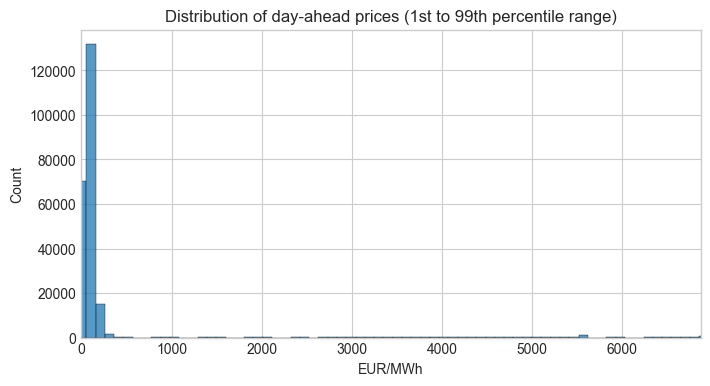

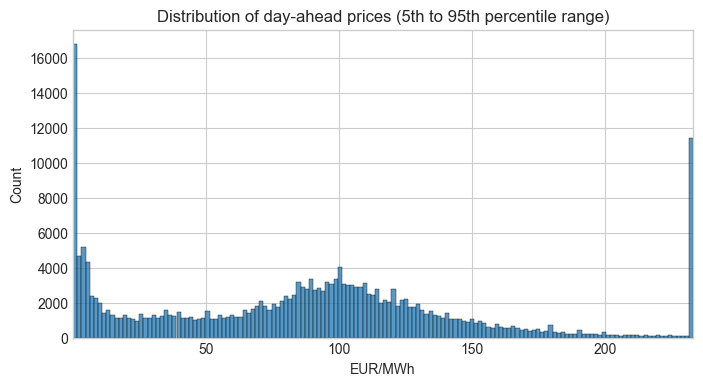

In [13]:
# Histogram
plt.figure(figsize=(8, 4))
sns.histplot(core["price_eur_mwh"].dropna(), bins=150, kde=False)
plt.xlim(core["price_eur_mwh"].quantile(0.01), core["price_eur_mwh"].quantile(0.99))
plt.title("Distribution of day-ahead prices (1st to 99th percentile range)")
plt.xlabel("EUR/MWh")
plt.show()

# Histogram less extreme zoom
plt.figure(figsize=(8, 4))
sns.histplot(core["price_eur_mwh"].dropna().clip(upper=core["price_eur_mwh"].quantile(0.95)).clip(lower=core["price_eur_mwh"].quantile(0.05)), bins=150, kde=False)
plt.xlim(core["price_eur_mwh"].quantile(0.05), core["price_eur_mwh"].quantile(0.95))
plt.title("Distribution of day-ahead prices (5th to 95th percentile range)")
plt.xlabel("EUR/MWh")
plt.show()

In [14]:
# Add calendar features
core["hour_utc"] = core["datetime_utc"].dt.hour
core["dayofweek"] = core["datetime_utc"].dt.dayofweek
core["month"] = core["datetime_utc"].dt.month
core["date"] = core["datetime_utc"].dt.date

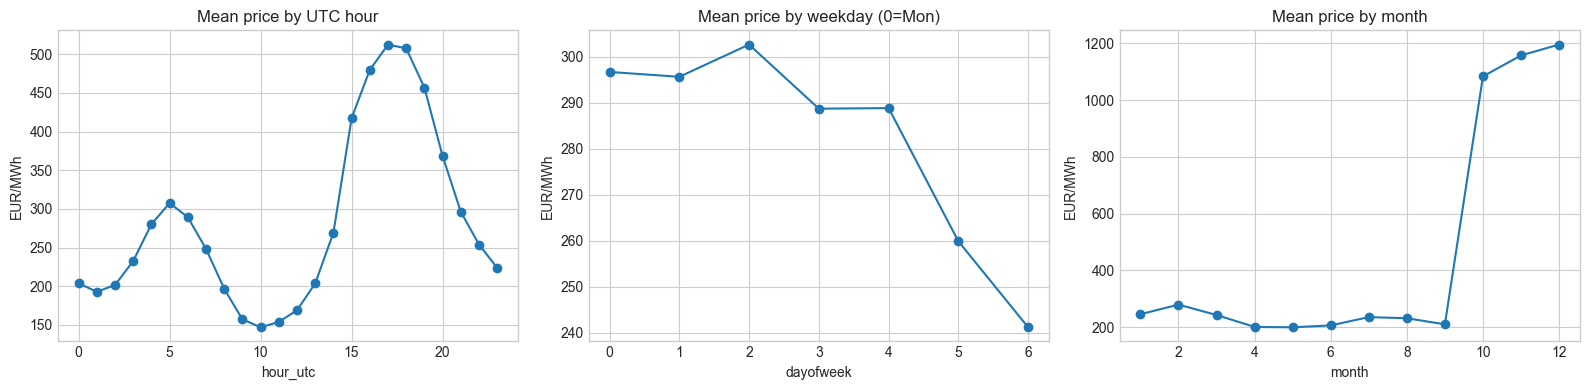

In [15]:
# Average pattern by hour and weekday across all zones
hour_profile = core.groupby("hour_utc")["price_eur_mwh"].mean()
dow_profile = core.groupby("dayofweek")["price_eur_mwh"].mean()
month_profile = core.groupby("month")["price_eur_mwh"].mean()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

hour_profile.plot(ax=axes[0], marker="o", title="Mean price by UTC hour")
dow_profile.plot(ax=axes[1], marker="o", title="Mean price by weekday (0=Mon)")
month_profile.plot(ax=axes[2], marker="o", title="Mean price by month")

for ax in axes:
    ax.set_ylabel("EUR/MWh")

plt.tight_layout()
plt.show()

In [16]:
# Rank zones by volatility
zone_vol = (
    core.groupby(["map_code", "area_name"])["price_eur_mwh"]
        .agg(["mean", "std", "min", "max"])
        .reset_index()
        .sort_values("std", ascending=False)
)

zone_vol.head(20)

,map_code,area_name,mean,std,min,max
36,UA_IPS,UA-IPS,5292.901774,3107.992192,10.00,15000.00
8,EE,Estonia (EE),78.408499,71.167582,-21.71,773.00
16,LT,Lithuania (LT),80.423684,69.006637,-23.58,773.00
17,LV,Latvia (LV),80.989501,68.728734,-23.58,773.00
2,BG,Bulgaria (BG),102.421881,62.025737,-100.63,603.30
14,HU,Hungary (HU),104.394493,61.820506,-210.05,615.15
29,RO,Romania (RO),104.064525,61.353795,-100.63,603.30
12,GR,Greece (GR),101.567598,59.086690,-50.00,471.56
35,SK,Slovakia (SK),100.654524,58.362334,-202.70,563.13
13,HR,Croatia (HR),102.168614,57.298391,-151.04,574.89


In [17]:
# Inspect available zone names/codes
zones = (
    core[["map_code", "area_name"]]
    .drop_duplicates()
    .sort_values(["map_code", "area_name"])
    .reset_index(drop=True)
)

zones[zones["area_name"].str.contains("France|Germany|DE|FR", case=False, na=False)]

,map_code,area_name
5,DE_LU,DE-LU
11,FR,France (FR)


Note: DE_LU is Germany + Luxembourg and FR is France.

In [18]:
# Build DE_LU and FR price series
target_codes = ["FR", "DE_LU"]

sub = core[core["map_code"].isin(target_codes)].copy()

wide = (
    sub.pivot_table(
        index="datetime_utc",
        columns="map_code",
        values="price_eur_mwh",
        aggfunc="last"
    )
    .sort_index()
)

wide.columns = [f"price_{c.lower()}" for c in wide.columns]
wide = wide.reset_index()

wide.head()

,datetime_utc,price_de_lu,price_fr
0,2025-01-01 00:00:00+00:00,1.60,18.92
1,2025-01-01 01:00:00+00:00,0.00,16.66
2,2025-01-01 02:00:00+00:00,-0.01,13.10
3,2025-01-01 03:00:00+00:00,-0.01,5.90
4,2025-01-01 04:00:00+00:00,-0.06,9.27


In [19]:
# Derived variables for time series / copulas / extremes / Hawkes
price_cols = [c for c in wide.columns if c.startswith("price_")]

for c in price_cols:
    wide[f"diff_{c}"] = wide[c].diff()
    wide[f"ret_{c}"] = np.log(wide[c].where(wide[c] > 0)).diff()

if len(price_cols) >= 2:
    wide["spread_12"] = wide[price_cols[0]] - wide[price_cols[1]]

# Event indicators
for c in price_cols:
    q95 = wide[c].quantile(0.95)
    wide[f"event_high_{c}"] = (wide[c] > q95).astype(int)
    wide[f"event_neg_{c}"] = (wide[c] < 0).astype(int)
    wide[f"event_jump_{c}"] = (wide[f"diff_{c}"].abs() > wide[f"diff_{c}"].abs().quantile(0.95)).astype(int)

wide.head()

,datetime_utc,price_de_lu,price_fr,diff_price_de_lu,ret_price_de_lu,diff_price_fr,ret_price_fr,spread_12,event_high_price_de_lu,event_neg_price_de_lu,event_jump_price_de_lu,event_high_price_fr,event_neg_price_fr,event_jump_price_fr
0,2025-01-01 00:00:00+00:00,1.60,18.92,NaN,NaN,NaN,NaN,-17.32,0,0,0,0,0,0
1,2025-01-01 01:00:00+00:00,0.00,16.66,-1.60,NaN,-2.26,-0.127209,-16.66,0,0,0,0,0,0
2,2025-01-01 02:00:00+00:00,-0.01,13.10,-0.01,NaN,-3.56,-0.240398,-13.11,0,1,0,0,0,0
3,2025-01-01 03:00:00+00:00,-0.01,5.90,0.00,NaN,-7.20,-0.797660,-5.91,0,1,0,0,0,0
4,2025-01-01 04:00:00+00:00,-0.06,9.27,-0.05,NaN,3.37,0.451831,-9.33,0,1,0,0,0,0


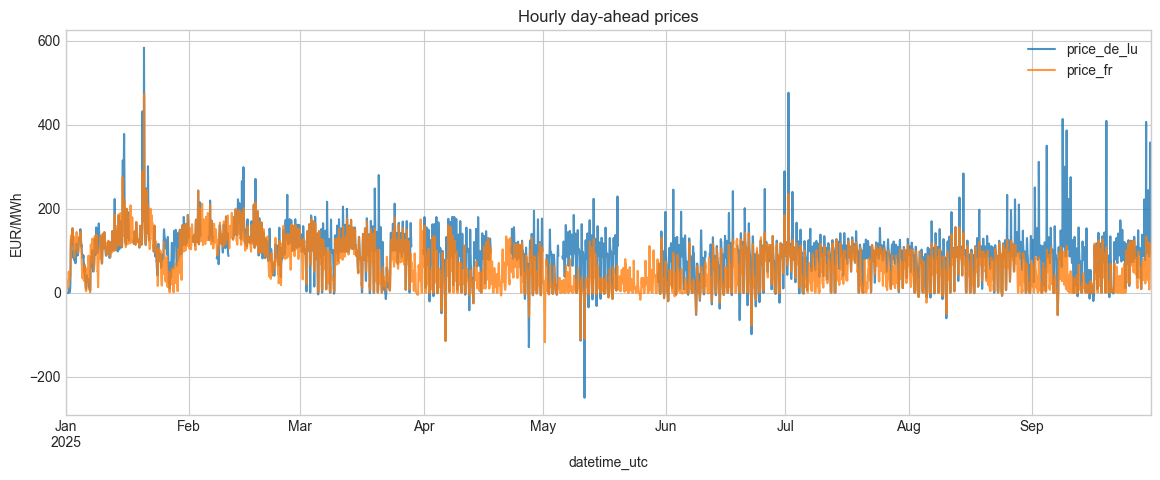

In [20]:
# FR/DE time series
ax = wide.set_index("datetime_utc")[price_cols].plot(figsize=(14, 5), alpha=0.8)
ax.set_title("Hourly day-ahead prices")
ax.set_ylabel("EUR/MWh")
plt.show()

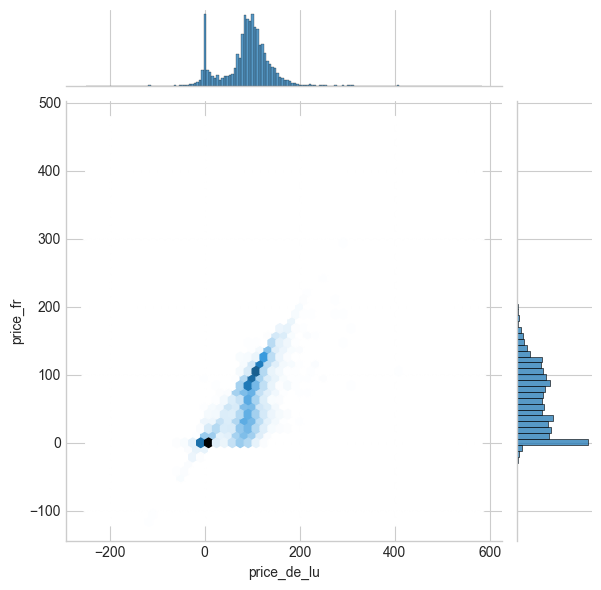

             price_de_lu  price_fr
price_de_lu     1.000000  0.745468
price_fr        0.745468  1.000000
             price_de_lu  price_fr
price_de_lu     1.000000  0.756951
price_fr        0.756951  1.000000


In [21]:
# Quick dependence analysis
if len(price_cols) >= 2:
    sns.jointplot(data=wide, x=price_cols[0], y=price_cols[1], kind="hex", height=6)
    plt.show()

    print(wide[price_cols].corr(method="pearson"))
    print(wide[price_cols].corr(method="spearman"))

In [22]:
# Save cleaned outputs
core.to_csv("entsoe_2025_energyprices_long_clean.csv", index=False)
wide.to_csv("entsoe_2025_fr_de_wide.csv", index=False)

## Analyse en séries temporelles

TODO: Maxime

## Analyse par la théorie des extrêmes

TODO: Thaïs

## Analyse par copules

Nous définissons $X_t$ et $Y_t$ comme les variations horaires désaisonnalisées des prix day-ahead français et allemands.  
Par le théorème de Sklar, la dépendance entre $X_t$ et $Y_t$ peut être séparée de leurs marges, ce qui motive la construction des pseudo-observations $(\hat U_t, \hat V_t)$.  
Nous commençons par des statistiques de rang, en particulier le tau de Kendall et le rho de Spearman, puis nous ajustons trois familles paramétriques : gaussienne, Gumbel et Clayton.  
L’estimation est menée de deux façons : inversion du tau de Kendall puis maximum de vraisemblance.  
Nous comparons ensuite les familles par log-vraisemblance, AIC, BIC et coefficients de dépendance de queue.

In [23]:
# Copulas setup
from scipy.stats import kendalltau, spearmanr, rankdata, norm
from scipy.optimize import minimize_scalar, minimize

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

fr_col = "price_fr"
de_col = "price_de_lu"

print("Using:", fr_col, de_col)

Using: price_fr price_de_lu


In [24]:
# Prepare X_t, Y_t : hoyrly price variations, then de-seasonalized by hour-of day and day-of-week effects, x is fr, y is de
cop_df = (
    wide[["datetime_utc", fr_col, de_col]]
    .dropna()
    .sort_values("datetime_utc")
    .copy()
)

cop_df["spread"] = cop_df[fr_col] - cop_df[de_col]
cop_df["d_fr"] = cop_df[fr_col].diff()
cop_df["d_de"] = cop_df[de_col].diff()

cop_df["hour"] = cop_df["datetime_utc"].dt.hour
cop_df["dow"] = cop_df["datetime_utc"].dt.dayofweek

cop_df["x"] = cop_df["d_fr"] - cop_df.groupby(["hour", "dow"])["d_fr"].transform("mean")
cop_df["y"] = cop_df["d_de"] - cop_df.groupby(["hour", "dow"])["d_de"].transform("mean")

cop_df["rolling_vol"] = (
    cop_df["x"].abs().rolling(24, min_periods=12).mean() +
    cop_df["y"].abs().rolling(24, min_periods=12).mean()
)

stress_thr = cop_df["rolling_vol"].quantile(0.80)
spread_thr = cop_df["spread"].abs().quantile(0.90)

cop_df["regime"] = np.where(
    (cop_df["rolling_vol"] >= stress_thr) | (cop_df["spread"].abs() >= spread_thr),
    "stressed",
    "calm"
)

cop_df = cop_df.dropna(subset=["x", "y"]).reset_index(drop=True)

cop_df[["datetime_utc", fr_col, de_col, "x", "y", "spread", "rolling_vol", "regime"]].head()

,datetime_utc,price_fr,price_de_lu,x,y,spread,rolling_vol,regime
0,2025-01-01 01:00:00+00:00,16.66,0.00,1.635455,-0.527576,16.66,NaN,calm
1,2025-01-01 02:00:00+00:00,13.10,-0.01,-0.333333,-0.986970,13.11,NaN,calm
2,2025-01-01 03:00:00+00:00,5.90,-0.01,-11.815758,-7.198485,5.91,NaN,calm
3,2025-01-01 04:00:00+00:00,9.27,-0.06,-6.084848,-15.545152,9.33,NaN,calm
4,2025-01-01 05:00:00+00:00,10.04,-0.09,-18.330000,-14.337879,10.13,NaN,calm


In [25]:
# Pseudo-observations
def pseudo_obs(x):
    r = rankdata(x, method="average")
    return r / (len(x) + 1.0)

cop_df["u"] = pseudo_obs(cop_df["x"].values)
cop_df["v"] = pseudo_obs(cop_df["y"].values)

tau_hat = kendalltau(cop_df["x"], cop_df["y"]).statistic
rho_hat = spearmanr(cop_df["x"], cop_df["y"]).statistic

print("Kendall tau =", tau_hat)
print("Spearman rho =", rho_hat)

Kendall tau = 0.21770842022587744
Spearman rho = 0.30624837296441554


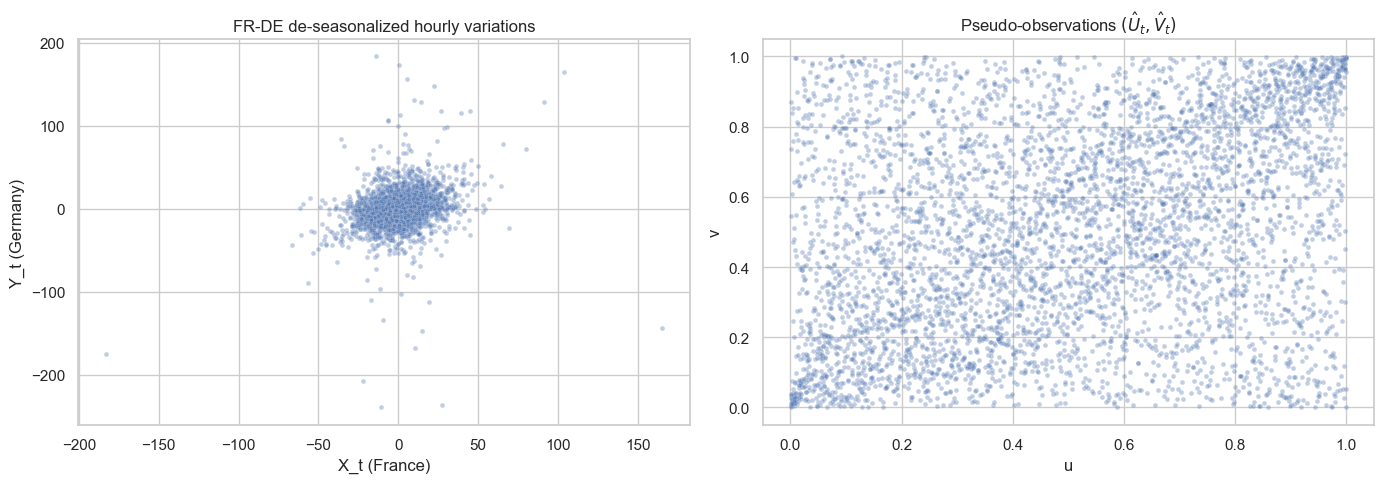

In [26]:
# Basic visuals raw scatter and pseudo variations
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(data=cop_df.sample(min(5000, len(cop_df)), random_state=42),
                x="x", y="y", s=12, alpha=0.35, ax=axes[0])
axes[0].set_title("FR-DE de-seasonalized hourly variations")
axes[0].set_xlabel("X_t (France)")
axes[0].set_ylabel("Y_t (Germany)")

sns.scatterplot(data=cop_df.sample(min(5000, len(cop_df)), random_state=42),
                x="u", y="v", s=12, alpha=0.35, ax=axes[1])
axes[1].set_title("Pseudo-observations $(\\hat U_t, \\hat V_t)$")
axes[1].set_xlabel("u")
axes[1].set_ylabel("v")

plt.tight_layout()
plt.show()

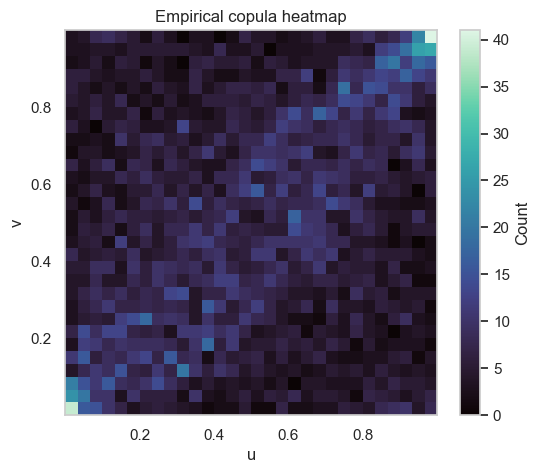

In [27]:
# Empirical copula heatmap
plt.figure(figsize=(6, 5))
plt.hist2d(cop_df["u"], cop_df["v"], bins=30, cmap="mako")
plt.colorbar(label="Count")
plt.xlabel("u")
plt.ylabel("v")
plt.title("Empirical copula heatmap")
plt.show()

In [28]:
# Copulas desnsities, log-likelihoods families Gaussian, Clayton, Gumbel
EPS = 1e-10

def clip_uv(u, v):
    u = np.clip(np.asarray(u, dtype=float), EPS, 1 - EPS)
    v = np.clip(np.asarray(v, dtype=float), EPS, 1 - EPS)
    return u, v

def gaussian_logpdf(u, v, rho):
    u, v = clip_uv(u, v)
    rho = float(np.clip(rho, -0.995, 0.995))
    z1 = norm.ppf(u)
    z2 = norm.ppf(v)
    out = (
        -0.5 * np.log(1 - rho**2)
        + (2 * rho * z1 * z2 - rho**2 * (z1**2 + z2**2)) / (2 * (1 - rho**2))
    )
    return out

def clayton_logpdf(u, v, theta):
    u, v = clip_uv(u, v)
    theta = float(theta)
    if theta <= 0:
        return np.full_like(u, -np.inf, dtype=float)
    A = u**(-theta) + v**(-theta) - 1
    out = (
        np.log1p(theta)
        + (-1 - theta) * (np.log(u) + np.log(v))
        + (-2 - 1/theta) * np.log(A)
    )
    return out

def gumbel_logpdf(u, v, theta):
    u, v = clip_uv(u, v)
    theta = float(theta)
    if theta < 1:
        return np.full_like(u, -np.inf, dtype=float)

    su = -np.log(u)
    sv = -np.log(v)
    A = su**theta + sv**theta
    C = np.exp(-(A**(1/theta)))

    out = (
        np.log(C)
        - np.log(u) - np.log(v)
        + (theta - 1) * (np.log(su) + np.log(sv))
        + (2/theta - 2) * np.log(A)
        + np.log(1 + (theta - 1) * A**(-1/theta))
    )
    return out

def copula_loglik(u, v, family, param):
    if family == "gaussian":
        ll = gaussian_logpdf(u, v, param)
    elif family == "clayton":
        ll = clayton_logpdf(u, v, param)
    elif family == "gumbel":
        ll = gumbel_logpdf(u, v, param)
    else:
        raise ValueError("Unknown family")
    if np.any(~np.isfinite(ll)):
        return -np.inf
    return np.sum(ll)

def param_from_tau(family, tau):
    if family == "gaussian":
        return np.sin(np.pi * tau / 2)
    elif family == "gumbel":
        if tau <= 0:
            return np.nan
        return 1.0 / (1.0 - tau)
    elif family == "clayton":
        if tau <= 0:
            return np.nan
        return 2.0 * tau / (1.0 - tau)
    else:
        raise ValueError("Unknown family")

def fit_copula_mle(u, v, family):
    if family == "gaussian":
        obj = lambda rho: -copula_loglik(u, v, family, rho)
        res = minimize_scalar(obj, bounds=(-0.95, 0.95), method="bounded")
        return res.x, -res.fun, res.success

    elif family == "gumbel":
        obj = lambda th: -copula_loglik(u, v, family, th)
        res = minimize_scalar(obj, bounds=(1.0001, 20.0), method="bounded")
        return res.x, -res.fun, res.success

    elif family == "clayton":
        obj = lambda th: -copula_loglik(u, v, family, th)
        res = minimize_scalar(obj, bounds=(1e-4, 20.0), method="bounded")
        return res.x, -res.fun, res.success

    else:
        raise ValueError("Unknown family")

def tail_dependence(family, param):
    if family == "gaussian":
        return 0.0, 0.0
    elif family == "gumbel":
        lam_u = 2 - 2**(1/param)
        lam_l = 0.0
        return lam_l, lam_u
    elif family == "clayton":
        lam_l = 2**(-1/param)
        lam_u = 0.0
        return lam_l, lam_u
    else:
        raise ValueError("Unknown family")


In [29]:
# Fit all families both inversion of tau and MLE
def fit_all_copulas(frame, label="full"):
    u = frame["u"].values
    v = frame["v"].values
    n = len(frame)

    tau = kendalltau(frame["x"], frame["y"]).statistic
    rho = spearmanr(frame["x"], frame["y"]).statistic

    rows = []
    for family in ["gaussian", "gumbel", "clayton"]:
        p_tau = param_from_tau(family, tau)
        ll_tau = np.nan if np.isnan(p_tau) else copula_loglik(u, v, family, p_tau)

        p_mle, ll_mle, success = fit_copula_mle(u, v, family)
        aic = 2 * 1 - 2 * ll_mle
        bic = np.log(n) * 1 - 2 * ll_mle
        lam_l, lam_u = tail_dependence(family, p_mle)

        rows.append({
            "regime": label,
            "family": family,
            "n": n,
            "tau_hat": tau,
            "rho_hat": rho,
            "param_tau": p_tau,
            "ll_tau": ll_tau,
            "param_mle": p_mle,
            "ll_mle": ll_mle,
            "AIC": aic,
            "BIC": bic,
            "lambda_l": lam_l,
            "lambda_u": lam_u,
            "success": success
        })

    return pd.DataFrame(rows)

cop_results_full = fit_all_copulas(cop_df, "full")
cop_results_calm = fit_all_copulas(cop_df.query("regime == 'calm'"), "calm")
cop_results_stress = fit_all_copulas(cop_df.query("regime == 'stressed'"), "stressed")

cop_results = pd.concat([cop_results_full, cop_results_calm, cop_results_stress], ignore_index=True)
cop_results.sort_values(["regime", "ll_mle"], ascending=[True, False])


,regime,family,n,tau_hat,rho_hat,param_tau,ll_tau,param_mle,ll_mle,AIC,BIC,lambda_l,lambda_u,success
4,calm,gumbel,4295,0.223119,0.316787,1.287198,295.817156,1.334104,299.859637,-597.719273,-591.354067,0.000000,0.318712,True
3,calm,gaussian,4295,0.223119,0.316787,0.343343,235.980365,0.365862,237.264808,-472.529616,-466.164410,0.000000,0.000000,True
5,calm,clayton,4295,0.223119,0.316787,0.574395,191.922653,0.502086,195.275928,-388.551856,-382.186649,0.251444,0.000000,True
1,full,gumbel,5854,0.217708,0.306248,1.278296,392.166315,1.277330,392.169206,-782.338411,-775.663531,0.000000,0.279434,True
0,full,gaussian,5854,0.217708,0.306248,0.335349,294.664662,0.311304,297.006382,-592.012765,-585.337884,0.000000,0.000000,True
2,full,clayton,5854,0.217708,0.306248,0.556591,215.655485,0.393827,245.291543,-488.583087,-481.908206,0.172040,0.000000,True
7,stressed,gumbel,1559,0.207275,0.288781,1.261471,101.413923,1.192585,107.910695,-213.821390,-208.469590,0.000000,0.211792,True
6,stressed,gaussian,1559,0.207275,0.288781,0.319865,64.613749,0.236399,75.999915,-149.999830,-144.648030,0.000000,0.000000,True
8,stressed,clayton,1559,0.207275,0.288781,0.522943,31.451462,0.263268,67.738444,-133.476888,-128.125088,0.071873,0.000000,True


In [30]:
# Summary table
summary_cols = [
    "regime", "family", "tau_hat", "rho_hat",
    "param_tau", "param_mle", "ll_tau", "ll_mle",
    "AIC", "BIC", "lambda_l", "lambda_u"
]
cop_results[summary_cols].round(4)

,regime,family,tau_hat,rho_hat,param_tau,param_mle,ll_tau,ll_mle,AIC,BIC,lambda_l,lambda_u
0,full,gaussian,0.2177,0.3062,0.3353,0.3113,294.6647,297.0064,-592.0128,-585.3379,0.0000,0.0000
1,full,gumbel,0.2177,0.3062,1.2783,1.2773,392.1663,392.1692,-782.3384,-775.6635,0.0000,0.2794
2,full,clayton,0.2177,0.3062,0.5566,0.3938,215.6555,245.2915,-488.5831,-481.9082,0.1720,0.0000
3,calm,gaussian,0.2231,0.3168,0.3433,0.3659,235.9804,237.2648,-472.5296,-466.1644,0.0000,0.0000
4,calm,gumbel,0.2231,0.3168,1.2872,1.3341,295.8172,299.8596,-597.7193,-591.3541,0.0000,0.3187
5,calm,clayton,0.2231,0.3168,0.5744,0.5021,191.9227,195.2759,-388.5519,-382.1866,0.2514,0.0000
6,stressed,gaussian,0.2073,0.2888,0.3199,0.2364,64.6137,75.9999,-149.9998,-144.6480,0.0000,0.0000
7,stressed,gumbel,0.2073,0.2888,1.2615,1.1926,101.4139,107.9107,-213.8214,-208.4696,0.0000,0.2118
8,stressed,clayton,0.2073,0.2888,0.5229,0.2633,31.4515,67.7384,-133.4769,-128.1251,0.0719,0.0000


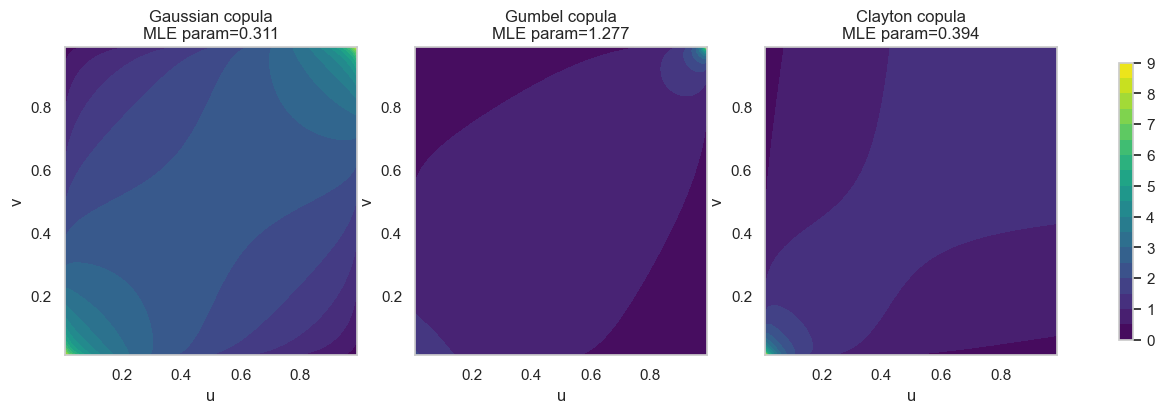

In [31]:
# Density contours for fitted copulas use MLE parameter on full sample
u_grid = np.linspace(0.01, 0.99, 120)
v_grid = np.linspace(0.01, 0.99, 120)
U, V = np.meshgrid(u_grid, v_grid)

def copula_density_grid(family, param, U, V):
    uu = U.ravel()
    vv = V.ravel()
    if family == "gaussian":
        Z = np.exp(gaussian_logpdf(uu, vv, param))
    elif family == "gumbel":
        Z = np.exp(gumbel_logpdf(uu, vv, param))
    elif family == "clayton":
        Z = np.exp(clayton_logpdf(uu, vv, param))
    else:
        raise ValueError("Unknown family")
    return Z.reshape(U.shape)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, family in zip(axes, ["gaussian", "gumbel", "clayton"]):
    param = cop_results.query("regime == 'full' and family == @family")["param_mle"].iloc[0]
    Z = copula_density_grid(family, param, U, V)
    cs = ax.contourf(U, V, Z, levels=18, cmap="viridis")
    ax.set_title(f"{family.capitalize()} copula\nMLE param={param:.3f}")
    ax.set_xlabel("u")
    ax.set_ylabel("v")

fig.colorbar(cs, ax=axes, shrink=0.9)
# plt.tight_layout()
plt.show()


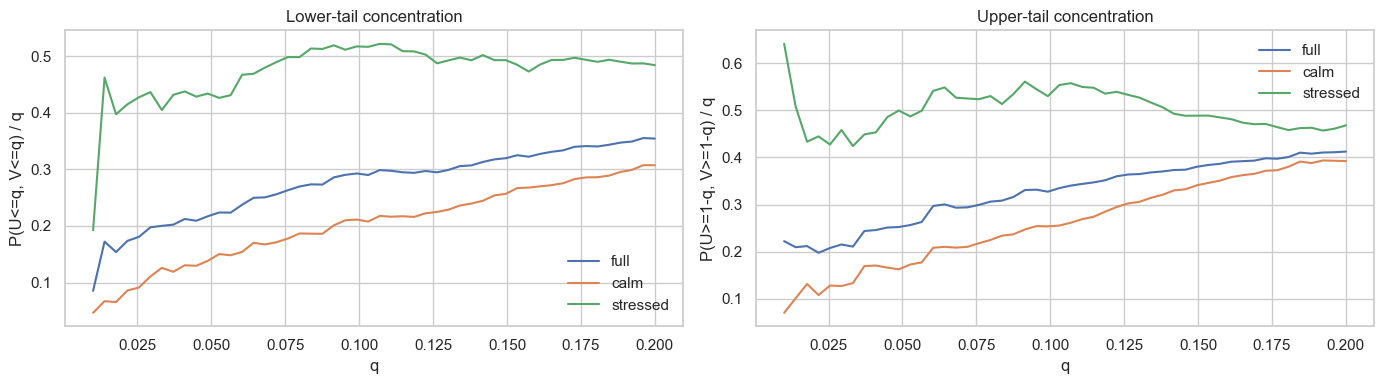

In [32]:
# Empirical tail concentration, useful for discussion on lower and upper tails
def empirical_tail_concentration(u, v, q_grid=None):
    if q_grid is None:
        q_grid = np.linspace(0.01, 0.20, 50)

    lower = []
    upper = []
    for q in q_grid:
        lower.append(np.mean((u <= q) & (v <= q)) / q)
        upper.append(np.mean((u >= 1 - q) & (v >= 1 - q)) / q)

    return pd.DataFrame({"q": q_grid, "lower": lower, "upper": upper})

tail_full = empirical_tail_concentration(cop_df["u"].values, cop_df["v"].values)
tail_calm = empirical_tail_concentration(
    cop_df.query("regime == 'calm'")["u"].values,
    cop_df.query("regime == 'calm'")["v"].values
)
tail_stress = empirical_tail_concentration(
    cop_df.query("regime == 'stressed'")["u"].values,
    cop_df.query("regime == 'stressed'")["v"].values
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(tail_full["q"], tail_full["lower"], label="full")
axes[0].plot(tail_calm["q"], tail_calm["lower"], label="calm")
axes[0].plot(tail_stress["q"], tail_stress["lower"], label="stressed")
axes[0].set_title("Lower-tail concentration")
axes[0].set_xlabel("q")
axes[0].set_ylabel("P(U<=q, V<=q) / q")
axes[0].legend()

axes[1].plot(tail_full["q"], tail_full["upper"], label="full")
axes[1].plot(tail_calm["q"], tail_calm["upper"], label="calm")
axes[1].plot(tail_stress["q"], tail_stress["upper"], label="stressed")
axes[1].set_title("Upper-tail concentration")
axes[1].set_xlabel("q")
axes[1].set_ylabel("P(U>=1-q, V>=1-q) / q")
axes[1].legend()

plt.tight_layout()
plt.show()


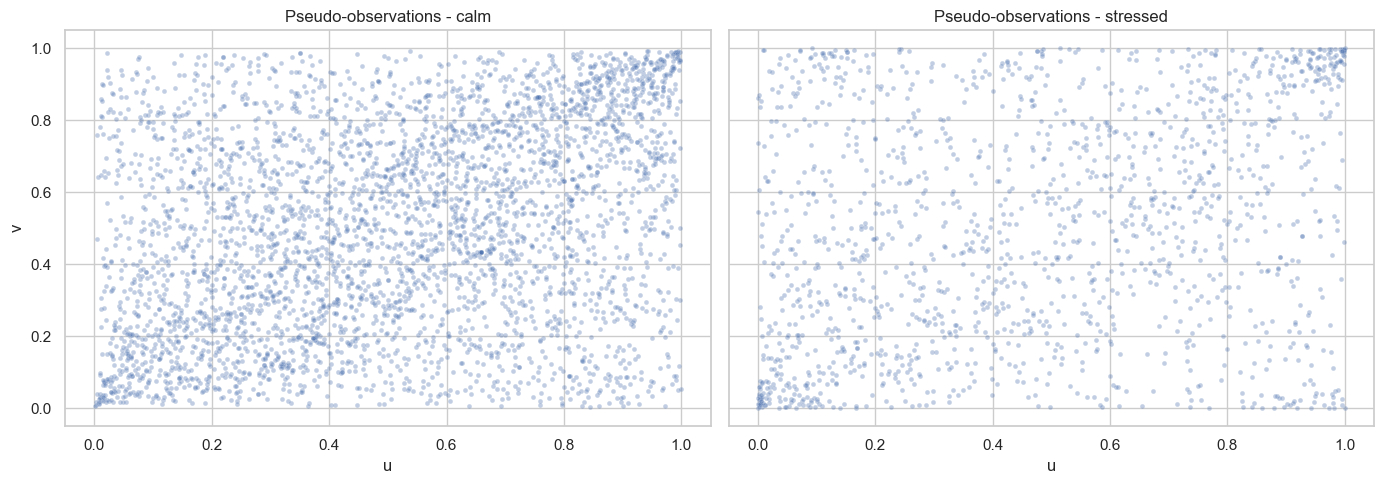

In [33]:
# Scatter by regime
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True, sharey=True)

for ax, regime in zip(axes, ["calm", "stressed"]):
    tmp = cop_df.query("regime == @regime").sample(min(4000, len(cop_df.query("regime == @regime"))), random_state=42)
    sns.scatterplot(data=tmp, x="u", y="v", s=12, alpha=0.35, ax=ax)
    ax.set_title(f"Pseudo-observations - {regime}")
    ax.set_xlabel("u")
    ax.set_ylabel("v")

plt.tight_layout()
plt.show()

### Analyse des résultats — Copules

Les statistiques de rang obtenues sur l’échantillon complet indiquent une dépendance positive mais modérée entre les variations horaires désaisonnalisées des prix français et allemands, avec un tau de Kendall égal à 0.2177 et un rho de Spearman égal à 0.3062. Cette première étape montre qu’il existe une co-dépendance non négligeable entre les deux marchés, mais pas au point de suggérer une quasi-colinéarité : les deux séries restent liées tout en conservant une part d’autonomie.

La comparaison des familles paramétriques montre très nettement que la copule de Gumbel domine les deux autres, et ce dans tous les régimes étudiés. Sur l’échantillon complet, elle obtient la meilleure log-vraisemblance (392.17 contre 297.01 pour la gaussienne et 245.29 pour la Clayton), ainsi que les meilleurs critères AIC et BIC. Le même classement apparaît dans le régime calme, puis dans le régime tendu, ce qui donne un résultat particulièrement robuste : la dépendance entre les marchés français et allemand est mieux décrite par une structure asymétrique de type Gumbel que par une copule elliptique gaussienne ou une copule de Clayton.

Ce résultat a une interprétation économique directe. La copule gaussienne, bien qu’utile comme référence, impose une dépendance symétrique sans dépendance de queue (elle ne les modélise pas). À l’inverse, la copule de Gumbel autorise une dépendance de queue supérieure, ce qui correspond ici à l’idée que les fortes hausses de prix ont tendance à se produire conjointement entre la France et l’Allemagne. La copule de Clayton, orientée vers la queue inférieure, est moins bien adaptée aux données dans cette étude, ce qui suggère que la dépendance la plus marquée ne concerne pas principalement les épisodes de prix très bas ou négatifs. Ce qui oriente notre analyse de Hawkes vers les événements de forte hausse plutôt que de forte baisse.

Les paramètres estimés confirment cette lecture. Pour l’échantillon complet, la copule de Gumbel estimée par maximum de vraisemblance donne un paramètre de 1.2773, soit un coefficient de dépendance de queue supérieure $\lambda_u \approx 0.2794$, alors que la dépendance de queue est nulle dans le modèle gaussien et reste plus faible, mais cette fois en queue inférieure, dans le modèle de Clayton ($\lambda_l \approx 0.1720$). On observe donc une asymétrie claire : les extrêmes haussiers sont davantage synchronisés entre les deux marchés que les extrêmes baissiers.

L’analyse par régime affine encore cette conclusion. En régime calme, la dépendance globale est légèrement plus forte ($\tau = 0.2231$, $\rho = 0.3168$) qu’en régime tendu ($\tau = 0.2073$, $\rho = 0.2888$). Toutefois, la structure de dépendance demeure dominée par Gumbel dans les deux cas, avec une queue supérieure plus marquée en régime calme ($\lambda_u \approx 0.3187$) qu’en régime tendu ($\lambda_u \approx 0.2118$). Ce point peut sembler contre-intuitif au premier abord, mais il suggère que les périodes qualifiées de “stressed” dans notre partition ne correspondent pas nécessairement à des co-extrêmes plus concentrés dans les tout derniers quantiles ; elles peuvent aussi refléter une dispersion accrue, des tensions plus hétérogènes, ou des mécanismes de marché plus désynchronisés.

Les graphes de concentration de queue vont dans le même sens. Du côté de la queue inférieure, la concentration décroît lentement puis semble converger vers zéro pour les plus petites valeurs de $q$, ce qui ne plaide pas pour une dépendance extrême basse très forte. En revanche, la queue supérieure paraît plus structurée : sur l’échantillon complet, la concentration reste positive, tandis qu’en régime tendu elle devient plus irrégulière et semble même augmenter pour certains très petits niveaux de $q$. Cette instabilité en petit échantillon doit être interprétée avec prudence, mais elle est compatible avec l’idée que les épisodes de très fortes hausses communes existent bien, même s’ils sont rares.

Au total, la conclusion de cette section est que la dépendance franco-allemande ne se réduit pas à une corrélation linéaire moyenne. Elle présente une composante asymétrique, mieux captée par une copule de Gumbel, ce qui signifie que les deux marchés ont surtout tendance à devenir extrêmes ensemble lors des hausses fortes de prix. Pour le mémoire, cela constitue un résultat intéressant : la dépendance pertinente du système n’est pas seulement une dépendance “au centre”, mais une dépendance de queue supérieure, cohérente avec des périodes de tension commune sur le marché électrique européen.


In [34]:
# Export tables
cop_results.to_csv("copula_results_fr_de.csv", index=False)
cop_df.to_csv("copula_analysis_frame_fr_de.csv", index=False)

## Analyse par les processus de Hawkes

Nous ne modélisons pas directement les prix comme un processus ponctuel.  
Nous transformons la série horaire en une suite d’événements extrêmes, par exemple $P_t<0$, $P_t>q_{0.95}$ ou $|\Delta P_t|>q_{0.95}$.  
Nous commençons par un Hawkes univarié en France puis en Allemagne, avec noyau exponentiel $\phi(t)=\alpha e^{-\beta t}\mathbf{1}_{t>0}$.  
Nous interprétons ensuite $\mu$ comme taux de base, $\alpha$ et $\beta$ comme paramètres d’auto-excitation, et le branching ratio $\alpha/\beta$ comme mesure du degré de clustering.  
Enfin, nous estimons un Hawkes bivarié pour étudier l’auto-excitation et l’excitation croisée entre les marchés français et allemand.


### Analyse des prix bas

In [35]:
# Events construction
hawkes_df = (
    wide[["datetime_utc", fr_col, de_col]]
    .dropna()
    .sort_values("datetime_utc")
    .copy()
)

hawkes_df["spread"] = hawkes_df[fr_col] - hawkes_df[de_col]
hawkes_df["d_fr"] = hawkes_df[fr_col].diff()
hawkes_df["d_de"] = hawkes_df[de_col].diff()

q95_fr = hawkes_df[fr_col].quantile(0.95)
q99_fr = hawkes_df[fr_col].quantile(0.99)
q95_de = hawkes_df[de_col].quantile(0.95)
q99_de = hawkes_df[de_col].quantile(0.99)

qd95_fr = hawkes_df["d_fr"].abs().quantile(0.95)
qd95_de = hawkes_df["d_de"].abs().quantile(0.95)
qspread95 = hawkes_df["spread"].abs().quantile(0.95)

event_catalog = {
    "negative_price": {
        "FR": hawkes_df[fr_col] < 0,
        "DE": hawkes_df[de_col] < 0,
    },
    "high_price_95": {
        "FR": hawkes_df[fr_col] > q95_fr,
        "DE": hawkes_df[de_col] > q95_de,
    },
    "high_price_99": {
        "FR": hawkes_df[fr_col] > q99_fr,
        "DE": hawkes_df[de_col] > q99_de,
    },
    "jump_95": {
        "FR": hawkes_df["d_fr"].abs() > qd95_fr,
        "DE": hawkes_df["d_de"].abs() > qd95_de,
    },
    "spread_extreme_95": {
        "FR": hawkes_df["spread"].abs() > qspread95,
        "DE": hawkes_df["spread"].abs() > qspread95,
    },
}

summary_rows = []
for event_name, masks in event_catalog.items():
    summary_rows.append({
        "event": event_name,
        "FR_count": int(masks["FR"].sum()),
        "DE_count": int(masks["DE"].sum()),
        "FR_share": float(masks["FR"].mean()),
        "DE_share": float(masks["DE"].mean()),
    })

event_summary = pd.DataFrame(summary_rows).sort_values("FR_count", ascending=False)
event_summary


,event,FR_count,DE_count,FR_share,DE_share
0,negative_price,434,459,0.074125,0.078395
1,high_price_95,293,293,0.050043,0.050043
3,jump_95,293,293,0.050043,0.050043
4,spread_extreme_95,293,293,0.050043,0.050043
2,high_price_99,59,59,0.010077,0.010077


In [36]:
# Choice of event type (negative price events)
selected_event = "negative_price"

hawkes_df["event_fr"] = event_catalog[selected_event]["FR"].astype(int)
hawkes_df["event_de"] = event_catalog[selected_event]["DE"].astype(int)

hawkes_df[["datetime_utc", "event_fr", "event_de"]].head()

,datetime_utc,event_fr,event_de
0,2025-01-01 00:00:00+00:00,0,0
1,2025-01-01 01:00:00+00:00,0,0
2,2025-01-01 02:00:00+00:00,0,1
3,2025-01-01 03:00:00+00:00,0,1
4,2025-01-01 04:00:00+00:00,0,1


In [37]:
# Event times in hours
origin = hawkes_df["datetime_utc"].min()
T = (hawkes_df["datetime_utc"].max() - origin).total_seconds() / 3600.0

fr_times = ((hawkes_df.loc[hawkes_df["event_fr"] == 1, "datetime_utc"] - origin)
            .dt.total_seconds() / 3600.0).to_numpy()

de_times = ((hawkes_df.loc[hawkes_df["event_de"] == 1, "datetime_utc"] - origin)
            .dt.total_seconds() / 3600.0).to_numpy()

print("Observation window length (hours):", T)
print("FR events:", len(fr_times))
print("DE events:", len(de_times))

Observation window length (hours): 6549.0
FR events: 434
DE events: 459


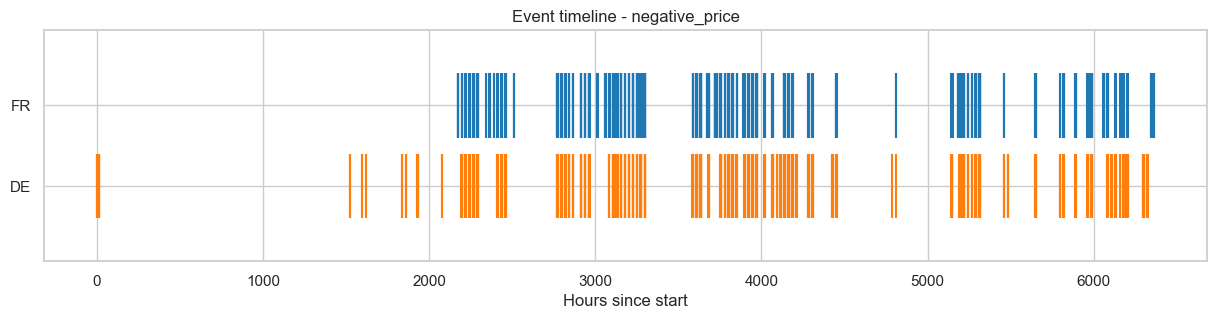

In [38]:
# Timeline / raster plot over the year
plt.figure(figsize=(15, 3))
plt.eventplot([fr_times, de_times], lineoffsets=[1, 0], linelengths=0.8, colors=["tab:blue", "tab:orange"])
plt.yticks([0, 1], ["DE", "FR"])
plt.xlabel("Hours since start")
plt.title(f"Event timeline - {selected_event}")
plt.show()

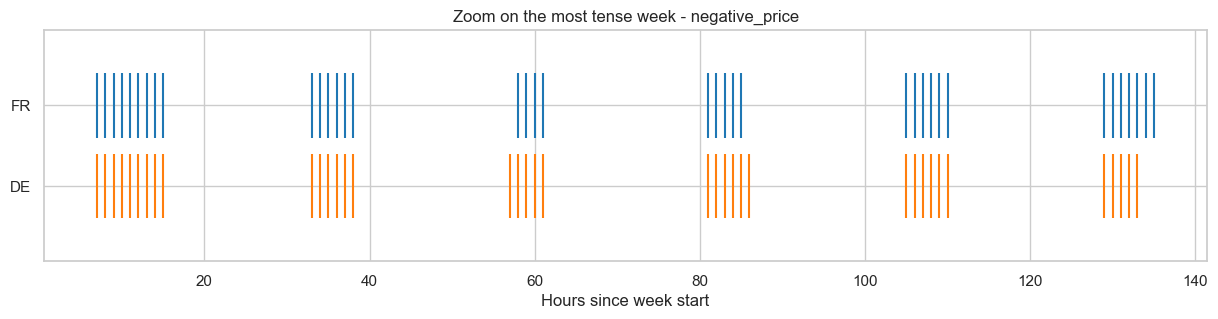

Zoom week: 2025-05-11 00:00:00+00:00 to 2025-05-17 00:00:00+00:00


In [39]:
# Zoom on most tense week from 7-day rolling sum of events
tmp = hawkes_df.set_index("datetime_utc")[["event_fr", "event_de"]].resample("D").sum()
tmp["total"] = tmp["event_fr"] + tmp["event_de"]
rolling7 = tmp["total"].rolling(7, min_periods=3).sum()

zoom_end = rolling7.idxmax()
zoom_start = zoom_end - pd.Timedelta(days=6)

zoom_df = hawkes_df[(hawkes_df["datetime_utc"] >= zoom_start) & (hawkes_df["datetime_utc"] <= zoom_end)].copy()
zoom_origin = zoom_start

fr_zoom = ((zoom_df.loc[zoom_df["event_fr"] == 1, "datetime_utc"] - zoom_origin).dt.total_seconds() / 3600.0).to_numpy()
de_zoom = ((zoom_df.loc[zoom_df["event_de"] == 1, "datetime_utc"] - zoom_origin).dt.total_seconds() / 3600.0).to_numpy()

plt.figure(figsize=(15, 3))
plt.eventplot([fr_zoom, de_zoom], lineoffsets=[1, 0], linelengths=0.8, colors=["tab:blue", "tab:orange"])
plt.yticks([0, 1], ["DE", "FR"])
plt.xlabel("Hours since week start")
plt.title(f"Zoom on the most tense week - {selected_event}")
plt.show()

print("Zoom week:", zoom_start, "to", zoom_end)


In [40]:
# Univariate exponential Hawkes MLE lambda(t) = mu + alpha * sum_{t_i < t} exp(-beta * (t - t_i)), branching alpha / beta
PENALTY = 1e12

def safe_positive_exp_sum(target_times, source_times, beta):
    """
    For each target time t, compute sum_j exp(-beta * (t - s_j)) 1_{s_j < t}
    in a numerically safe way.
    """
    target_times = np.asarray(target_times, dtype=float)
    source_times = np.asarray(source_times, dtype=float)

    if len(target_times) == 0:
        return np.array([], dtype=float)
    if len(source_times) == 0:
        return np.zeros(len(target_times), dtype=float)

    diff = target_times[:, None] - source_times[None, :]
    pos_diff = np.where(diff > 0, diff, np.inf)
    return np.exp(-beta * pos_diff).sum(axis=1)

def hawkes_univariate_nll(log_params, times, T):
    mu, alpha, beta = np.exp(log_params)

    if mu <= 0 or alpha < 0 or beta <= 0:
        return PENALTY

    branching = alpha / beta
    if branching >= 0.999:
        return PENALTY + 1e6 * (branching - 0.999) ** 2

    times = np.asarray(times, dtype=float)
    if len(times) == 0:
        return mu * T

    trigger_sum = safe_positive_exp_sum(times, times, beta)
    lam = mu + alpha * trigger_sum

    if np.any(~np.isfinite(lam)) or np.any(lam <= 0):
        return PENALTY

    integral = mu * T + (alpha / beta) * np.sum(1 - np.exp(-beta * (T - times)))
    ll = np.sum(np.log(lam)) - integral

    if not np.isfinite(ll):
        return PENALTY

    return -ll

def fit_univariate_hawkes(times, T):
    times = np.asarray(times, dtype=float)
    base_rate = max(len(times) / T, 1e-6)

    x0 = np.log([
        max(0.8 * base_rate, 1e-4),  # mu
        0.05,                        # alpha
        1.0                          # beta
    ])

    bounds = [
        (np.log(1e-6), np.log(5.0)),    # mu
        (np.log(1e-6), np.log(20.0)),   # alpha
        (np.log(1e-3), np.log(100.0))   # beta
    ]

    res = minimize(
        hawkes_univariate_nll,
        x0=x0,
        args=(times, T),
        method="L-BFGS-B",
        bounds=bounds
    )

    mu, alpha, beta = np.exp(res.x)
    branching = alpha / beta
    ll = -res.fun

    if branching < 1:
        lambda_bar = mu / (1 - branching)
        endogenous_share = branching
        exogenous_share = 1 - branching
    else:
        lambda_bar = np.nan
        endogenous_share = np.nan
        exogenous_share = np.nan

    return {
        "mu": mu,
        "alpha": alpha,
        "beta": beta,
        "branching_ratio": branching,
        "lambda_bar": lambda_bar,
        "endogenous_share": endogenous_share,
        "exogenous_share": exogenous_share,
        "loglik": ll,
        "success": bool(res.success and np.isfinite(ll) and ll < PENALTY / 10),
        "opt_result": res
    }

def hawkes_univariate_intensity(grid, times, mu, alpha, beta):
    grid = np.asarray(grid, dtype=float)
    times = np.asarray(times, dtype=float)
    trigger_sum = safe_positive_exp_sum(grid, times, beta)
    lam = mu + alpha * trigger_sum
    lam[~np.isfinite(lam)] = np.nan
    return lam


fit_fr_uni = fit_univariate_hawkes(fr_times, T)
fit_de_uni = fit_univariate_hawkes(de_times, T)

pd.DataFrame([fit_fr_uni, fit_de_uni], index=["FR", "DE"])[
    ["mu", "alpha", "beta", "branching_ratio", "lambda_bar", "endogenous_share", "exogenous_share", "loglik", "success"]
].round(4)


,mu,alpha,beta,branching_ratio,lambda_bar,endogenous_share,exogenous_share,loglik,success
FR,0.0139,0.4935,0.6240,0.7909,0.0663,0.7909,0.2091,-1073.1962,True
DE,0.0148,0.5065,0.6415,0.7895,0.0701,0.7895,0.2105,-1119.8032,True


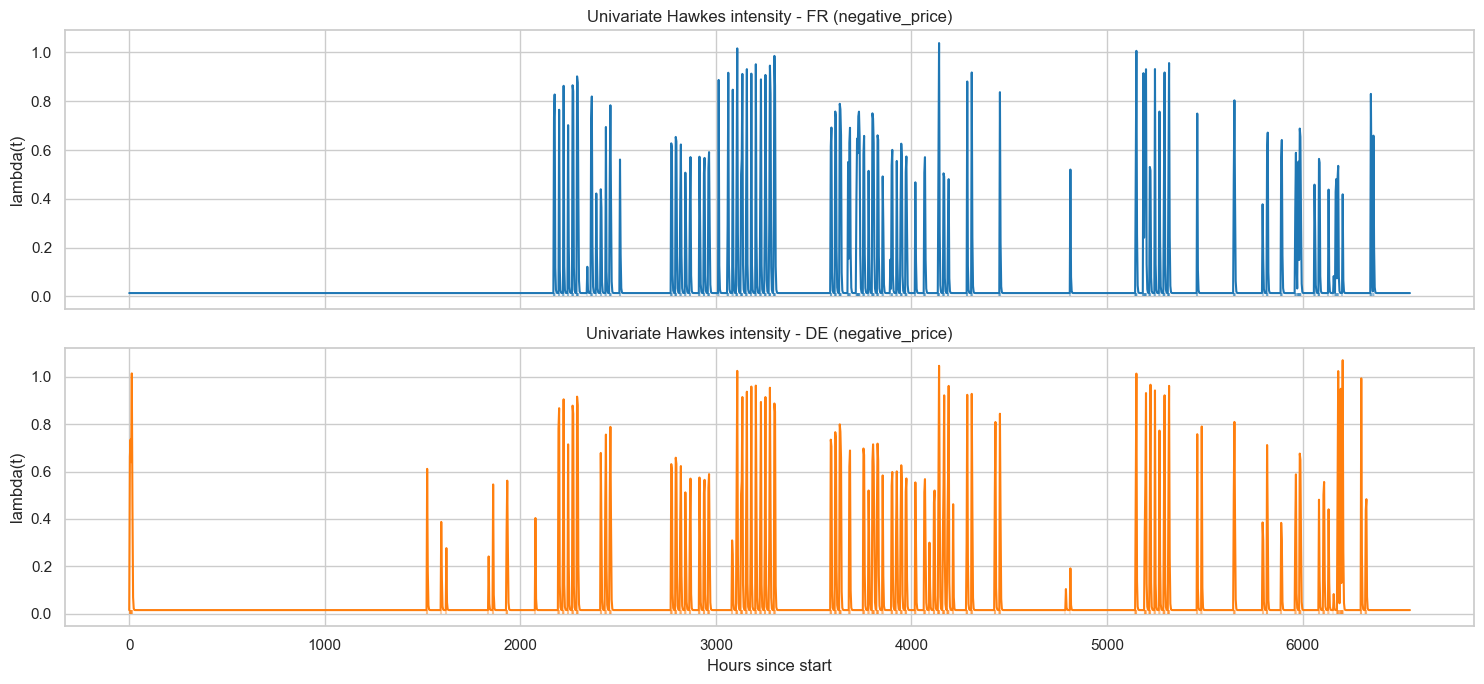

In [41]:
# Univariate intensity plots
grid_full = np.linspace(0, T, 2000)

lam_fr = hawkes_univariate_intensity(grid_full, fr_times, fit_fr_uni["mu"], fit_fr_uni["alpha"], fit_fr_uni["beta"])
lam_de = hawkes_univariate_intensity(grid_full, de_times, fit_de_uni["mu"], fit_de_uni["alpha"], fit_de_uni["beta"])

fig, axes = plt.subplots(2, 1, figsize=(15, 7), sharex=True)

axes[0].plot(grid_full, lam_fr, color="tab:blue")
axes[0].vlines(fr_times, ymin=0, ymax=np.quantile(lam_fr, 0.25), color="tab:blue", alpha=0.2)
axes[0].set_title(f"Univariate Hawkes intensity - FR ({selected_event})")
axes[0].set_ylabel("lambda(t)")

axes[1].plot(grid_full, lam_de, color="tab:orange")
axes[1].vlines(de_times, ymin=0, ymax=np.quantile(lam_de, 0.25), color="tab:orange", alpha=0.2)
axes[1].set_title(f"Univariate Hawkes intensity - DE ({selected_event})")
axes[1].set_ylabel("lambda(t)")
axes[1].set_xlabel("Hours since start")

plt.tight_layout()
plt.show()

In [42]:
# Bivariate exponential hawkes lambda_i(t) = mu_i + sum_j alpha_ij * sum_{t_k^j < t} exp(-beta_ij * (t - t_k^j))
def unpack_bivariate_params(log_params):
    p = np.exp(log_params)
    mu = np.array([p[0], p[1]])
    alpha = np.array([[p[2], p[3]],
                      [p[4], p[5]]])
    beta = np.array([[p[6], p[7]],
                     [p[8], p[9]]])
    return mu, alpha, beta

def hawkes_bivariate_nll(log_params, times_list, T):
    mu, alpha, beta = unpack_bivariate_params(log_params)

    if np.any(mu <= 0) or np.any(alpha < 0) or np.any(beta <= 0):
        return PENALTY

    G = alpha / beta
    spectral_radius = np.max(np.abs(np.linalg.eigvals(G)))
    if spectral_radius >= 0.999:
        return PENALTY + 1e6 * (spectral_radius - 0.999) ** 2

    ll = 0.0

    for i in range(2):
        ti = np.asarray(times_list[i], dtype=float)
        lam = np.full(len(ti), mu[i], dtype=float)

        for j in range(2):
            tj = np.asarray(times_list[j], dtype=float)
            if len(ti) == 0 or len(tj) == 0:
                continue
            lam += alpha[i, j] * safe_positive_exp_sum(ti, tj, beta[i, j])

        if np.any(~np.isfinite(lam)) or np.any(lam <= 0):
            return PENALTY

        ll += np.sum(np.log(lam))
        ll -= mu[i] * T

        for j in range(2):
            tj = np.asarray(times_list[j], dtype=float)
            if len(tj) == 0:
                continue
            ll -= (alpha[i, j] / beta[i, j]) * np.sum(1 - np.exp(-beta[i, j] * (T - tj)))

    if not np.isfinite(ll):
        return PENALTY

    return -ll

def fit_bivariate_hawkes(times_list, T):
    rate_1 = max(len(times_list[0]) / T, 1e-6)
    rate_2 = max(len(times_list[1]) / T, 1e-6)

    x0 = np.log([
        max(0.8 * rate_1, 1e-4), max(0.8 * rate_2, 1e-4),  # mu
        0.05, 0.02,                                        # alpha row 1
        0.02, 0.05,                                        # alpha row 2
        1.0, 1.0, 1.0, 1.0                                 # beta
    ])

    bounds = [
        (np.log(1e-6), np.log(5.0)),   # mu1
        (np.log(1e-6), np.log(5.0)),   # mu2
        (np.log(1e-6), np.log(20.0)),  # a11
        (np.log(1e-6), np.log(20.0)),  # a12
        (np.log(1e-6), np.log(20.0)),  # a21
        (np.log(1e-6), np.log(20.0)),  # a22
        (np.log(1e-3), np.log(100.0)), # b11
        (np.log(1e-3), np.log(100.0)), # b12
        (np.log(1e-3), np.log(100.0)), # b21
        (np.log(1e-3), np.log(100.0)), # b22
    ]

    res = minimize(
        hawkes_bivariate_nll,
        x0=x0,
        args=(times_list, T),
        method="L-BFGS-B",
        bounds=bounds,
        options={"maxiter": 500}
    )

    mu, alpha, beta = unpack_bivariate_params(res.x)
    G = alpha / beta
    spectral_radius = np.max(np.abs(np.linalg.eigvals(G)))
    ll = -res.fun

    if spectral_radius < 1:
        lambda_bar = np.linalg.solve(np.eye(2) - G, mu)
        endogenous_share = 1 - mu / lambda_bar
    else:
        lambda_bar = np.array([np.nan, np.nan])
        endogenous_share = np.array([np.nan, np.nan])

    return {
        "mu": mu,
        "alpha": alpha,
        "beta": beta,
        "G": G,
        "spectral_radius": spectral_radius,
        "lambda_bar": lambda_bar,
        "endogenous_share": endogenous_share,
        "loglik": ll,
        "success": bool(res.success and np.isfinite(ll) and ll < PENALTY / 10),
        "opt_result": res
    }

def hawkes_bivariate_intensity(grid, times_list, mu, alpha, beta):
    grid = np.asarray(grid, dtype=float)
    out = np.zeros((2, len(grid)), dtype=float)

    for i in range(2):
        out[i] = mu[i]
        for j in range(2):
            out[i] += alpha[i, j] * safe_positive_exp_sum(grid, times_list[j], beta[i, j])

    out[~np.isfinite(out)] = np.nan
    return out

fit_bi = fit_bivariate_hawkes([fr_times, de_times], T)
fit_bi


{'mu': array([0.01137689, 0.01427548]),
 'alpha': array([[0.42806558, 0.09165271],
        [0.01802674, 0.49248387]]),
 'beta': array([[0.62163025, 0.69376694],
        [0.58479648, 0.6419474 ]]),
 'G': array([[0.68861769, 0.13210879],
        [0.03082566, 0.76717169]]),
 'spectral_radius': np.float64(0.8028281443569483),
 'lambda_bar': array([0.06627248, 0.07008757]),
 'endogenous_share': array([0.82833156, 0.7963194 ]),
 'loglik': np.float64(-2177.2126996237157),
 'success': True,
 'opt_result':   message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
   success: True
    status: 0
       fun: 2177.2126996237157
         x: [-4.476e+00 -4.249e+00 -8.485e-01 -2.390e+00 -4.016e+00
             -7.083e-01 -4.754e-01 -3.656e-01 -5.365e-01 -4.432e-01]
       nit: 28
       jac: [ 3.911e-03 -4.820e-03  7.367e-03 -5.912e-03  6.821e-04
              4.502e-03  5.457e-04  1.592e-03 -9.095e-05  6.776e-03]
      nfev: 473
      njev: 43
  hess_inv: <10x10 LbfgsInvHessProduct with dtype=f

In [43]:
# Bivariate summary tables
mu = fit_bi["mu"]
alpha = fit_bi["alpha"]
beta = fit_bi["beta"]
G = fit_bi["G"]

hawkes_param_table = pd.DataFrame({
    "mu": mu,
    "lambda_bar": fit_bi["lambda_bar"],
    "endogenous_share": fit_bi["endogenous_share"]
}, index=["FR", "DE"])

hawkes_kernel_table = pd.DataFrame(G, index=["FR<-FR", "DE<-FR"], columns=["from FR", "from DE"])
# Note: rows here are not labeled ideally for reading, so we also make a clean table below
hawkes_kernel_table_clean = pd.DataFrame(
    G,
    index=["FR target", "DE target"],
    columns=["FR source", "DE source"]
)

print("Log-likelihood:", fit_bi["loglik"])
print("Spectral radius:", fit_bi["spectral_radius"])
display(hawkes_param_table.round(4))
display(hawkes_kernel_table_clean.round(4))


Log-likelihood: -2177.2126996237157
Spectral radius: 0.8028281443569483


,mu,lambda_bar,endogenous_share
FR,0.0114,0.0663,0.8283
DE,0.0143,0.0701,0.7963


,FR source,DE source
FR target,0.6886,0.1321
DE target,0.0308,0.7672


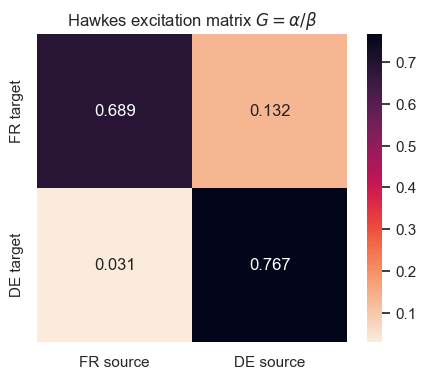

In [44]:
# Excitation matrix heatmap G_ij = alpha_ij / beta_ij
plt.figure(figsize=(5, 4))
sns.heatmap(
    fit_bi["G"],
    annot=True,
    fmt=".3f",
    cmap="rocket_r",
    xticklabels=["FR source", "DE source"],
    yticklabels=["FR target", "DE target"]
)
plt.title("Hawkes excitation matrix $G = \\alpha / \\beta$")
plt.show()

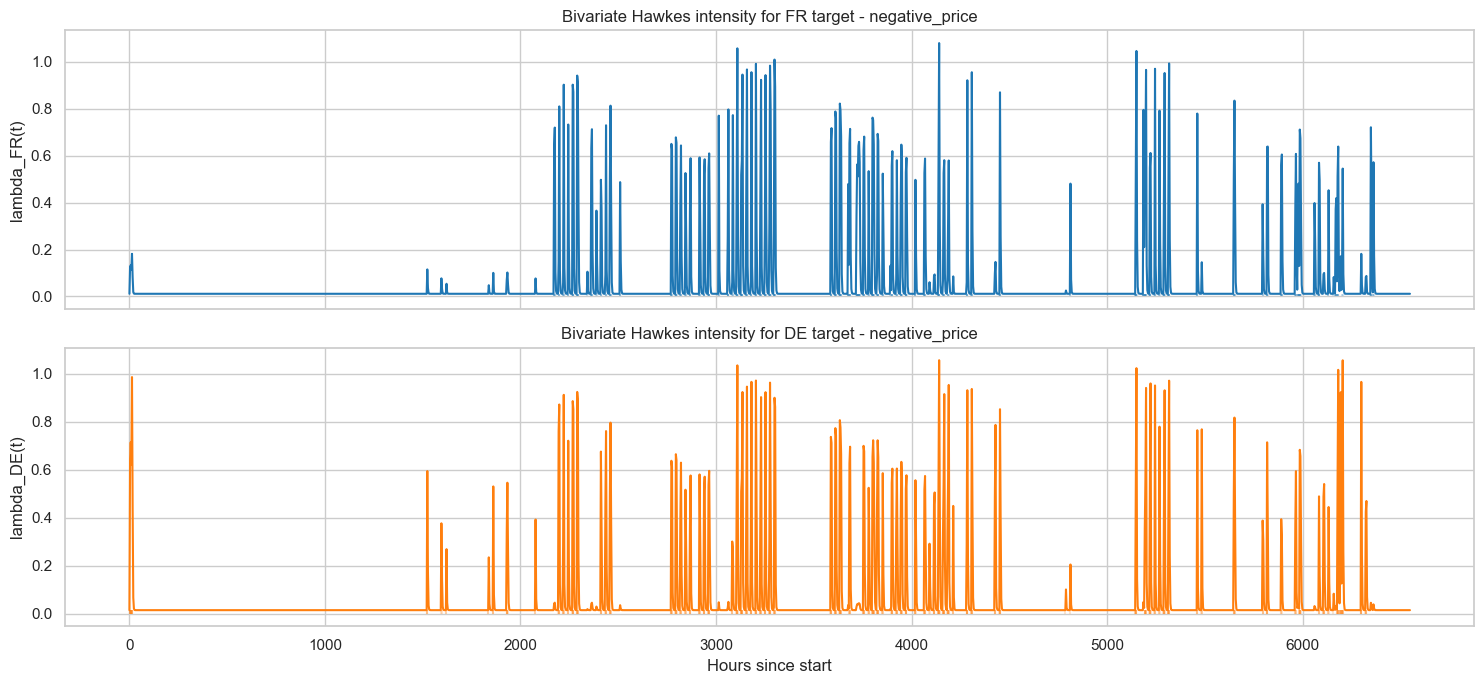

In [45]:
# Bivariate intensity over the full sample
grid_full = np.linspace(0, T, 2000)
lam_bi = hawkes_bivariate_intensity(grid_full, [fr_times, de_times], fit_bi["mu"], fit_bi["alpha"], fit_bi["beta"])

fig, axes = plt.subplots(2, 1, figsize=(15, 7), sharex=True)

axes[0].plot(grid_full, lam_bi[0], color="tab:blue")
axes[0].vlines(fr_times, ymin=0, ymax=np.quantile(lam_bi[0], 0.25), color="tab:blue", alpha=0.2)
axes[0].set_title(f"Bivariate Hawkes intensity for FR target - {selected_event}")
axes[0].set_ylabel("lambda_FR(t)")

axes[1].plot(grid_full, lam_bi[1], color="tab:orange")
axes[1].vlines(de_times, ymin=0, ymax=np.quantile(lam_bi[1], 0.25), color="tab:orange", alpha=0.2)
axes[1].set_title(f"Bivariate Hawkes intensity for DE target - {selected_event}")
axes[1].set_ylabel("lambda_DE(t)")
axes[1].set_xlabel("Hours since start")

plt.tight_layout()
plt.show()


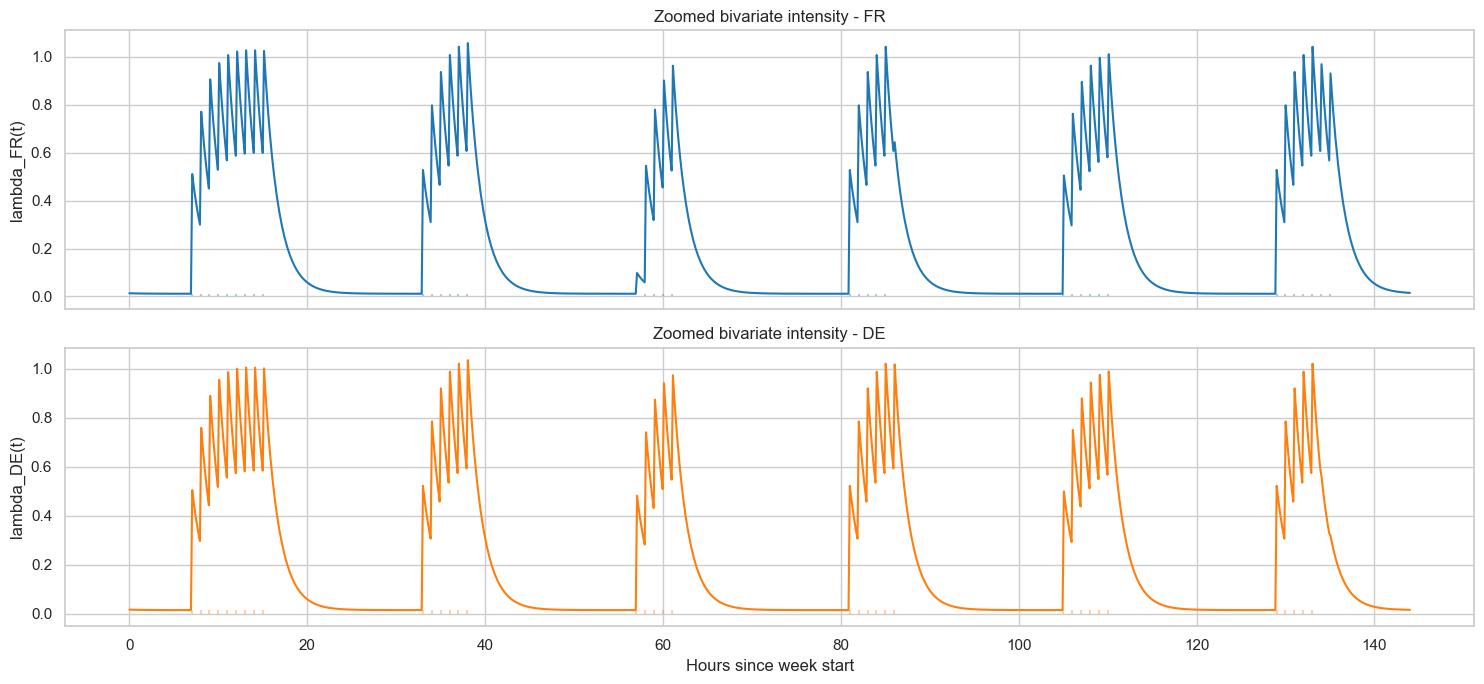

In [46]:
# Zoom intensity on the most tense week
zoom_start_h = (zoom_start - origin).total_seconds() / 3600.0
zoom_end_h = (zoom_end - origin).total_seconds() / 3600.0
grid_zoom = np.linspace(zoom_start_h, zoom_end_h, 1000)

lam_zoom = hawkes_bivariate_intensity(grid_zoom, [fr_times, de_times], fit_bi["mu"], fit_bi["alpha"], fit_bi["beta"])

fr_zoom_abs = fr_times[(fr_times >= zoom_start_h) & (fr_times <= zoom_end_h)]
de_zoom_abs = de_times[(de_times >= zoom_start_h) & (de_times <= zoom_end_h)]

fig, axes = plt.subplots(2, 1, figsize=(15, 7), sharex=True)

axes[0].plot(grid_zoom - zoom_start_h, lam_zoom[0], color="tab:blue")
axes[0].vlines(fr_zoom_abs - zoom_start_h, ymin=0, ymax=np.quantile(lam_zoom[0], 0.25), color="tab:blue", alpha=0.35)
axes[0].set_title("Zoomed bivariate intensity - FR")
axes[0].set_ylabel("lambda_FR(t)")

axes[1].plot(grid_zoom - zoom_start_h, lam_zoom[1], color="tab:orange")
axes[1].vlines(de_zoom_abs - zoom_start_h, ymin=0, ymax=np.quantile(lam_zoom[1], 0.25), color="tab:orange", alpha=0.35)
axes[1].set_title("Zoomed bivariate intensity - DE")
axes[1].set_ylabel("lambda_DE(t)")
axes[1].set_xlabel("Hours since week start")

plt.tight_layout()
plt.show()


In [47]:
# Export tables
event_summary.to_csv("hawkes_event_summary.csv", index=False)
hawkes_param_table.to_csv("hawkes_bivariate_node_summary.csv")
hawkes_kernel_table_clean.to_csv("hawkes_bivariate_excitation_matrix.csv")
hawkes_df.to_csv("hawkes_analysis_frame_fr_de.csv", index=False)


### Analyse des résultats

La première étape a consisté à transformer les séries horaires de prix en suites d’événements extrêmes. Pour les prix négatifs, nous observons 434 événements en France et 459 en Allemagne, soit respectivement 7.41 % et 7.84 % des observations horaires. Les événements associés aux seuils empiriques à 95 % représentent environ 5 % des observations, tandis que les événements à 99 % sont beaucoup plus rares, autour de 1 %. Cette fréquence justifie le choix d’une modélisation ponctuelle : les événements sont suffisamment nombreux pour être étudiés dynamiquement, tout en restant assez rares pour relever d’un cadre de pics ou de tensions de marché.

Les estimations univariées montrent une dynamique d’auto-excitation très nette dans les deux pays. En France, l’intensité de base est faible ($\mu \approx 0.0139$), alors que le branching ratio vaut environ 0.7909. En Allemagne, on obtient des ordres de grandeur très proches, avec $\mu \approx 0.0148$ et un branching ratio de 0.7895. Autrement dit, une part importante des événements observés n’est pas purement exogène : une fois qu’un épisode extrême apparaît, il tend à engendrer d’autres épisodes proches dans le temps.

Cette lecture est renforcée par la décomposition exogène/endogène. Les parts endogènes estimées sont proches de 79 % dans les deux pays, contre seulement 21 % environ pour la composante exogène. En pratique, cela signifie que les extrêmes ne se présentent pas comme des occurrences isolées ; ils arrivent plutôt en grappes temporelles, ce qui justifie pleinement l’usage d’un processus de Hawkes plutôt que d’un simple modèle de Poisson homogène.

Les estimations bivariées confirment d’abord la stabilité du modèle. Le rayon spectral de la matrice d’excitation vaut 0.8028, ce qui reste strictement inférieur à 1 ; le modèle est donc dans une zone stationnaire. Les intensités moyennes de long terme restent proches des résultats univariés, avec $\bar\lambda_{FR} \approx 0.0663$ et $\bar\lambda_{DE} \approx 0.0701$, ce qui assure une cohérence globale entre les deux approches.

La matrice d’excitation estimée apporte ensuite l’information la plus intéressante pour l’interprétation économique. Les effets diagonaux sont forts : $G_{FR,FR} \approx 0.6886$ et $G_{DE,DE} \approx 0.7672$. Cela indique une auto-excitation marquée dans chacun des deux marchés : lorsqu’un événement extrême survient dans un pays, il augmente fortement la probabilité d’apparition d’un nouvel événement du même type dans ce même pays à court terme.

Les effets croisés existent également, mais ils sont asymétriques. L’effet de l’Allemagne vers la France est sensiblement plus fort ($G_{FR,DE} \approx 0.1321$) que l’effet de la France vers l’Allemagne ($G_{DE,FR} \approx 0.0308$). Cette asymétrie suggère que, dans la définition d’événement retenue ici, les tensions observées sur le marché allemand ont davantage de capacité à se transmettre au marché français que l’inverse. Une telle lecture est économiquement plausible compte tenu du rôle central du marché allemand dans l’équilibre électrique régional.

Enfin, les parts endogènes issues du modèle bivarié sont encore plus élevées que dans les modèles univariés, autour de 82.8 % pour la France et 79.6 % pour l’Allemagne. Cela signifie qu’une fraction importante de l’activité extrême s’explique par des mécanismes de propagation interne au système franco-allemand, et pas seulement par des chocs extérieurs indépendants. En d’autres termes, les événements extrêmes sont non seulement clusterisés dans le temps, mais aussi partiellement propagés entre marchés.

La conclusion de cette section est donc double. D’une part, les négatifs sur les prix de l’électricité en 2025 présentent une forte auto-excitation temporelle. D’autre part, cette dynamique possède une composante transfrontalière identifiable, avec une excitation croisée plus marquée de l’Allemagne vers la France. Le cadre de Hawkes met ainsi en évidence une structure de contagion temporelle et spatiale que les seules statistiques descriptives ou corrélations statiques ne permettent pas de faire apparaître aussi clairement.


### Analyse des prix hauts

In [48]:
# Events construction
hawkes_df = (
    wide[["datetime_utc", fr_col, de_col]]
    .dropna()
    .sort_values("datetime_utc")
    .copy()
)

hawkes_df["spread"] = hawkes_df[fr_col] - hawkes_df[de_col]
hawkes_df["d_fr"] = hawkes_df[fr_col].diff()
hawkes_df["d_de"] = hawkes_df[de_col].diff()

q95_fr = hawkes_df[fr_col].quantile(0.95)
q99_fr = hawkes_df[fr_col].quantile(0.99)
q95_de = hawkes_df[de_col].quantile(0.95)
q99_de = hawkes_df[de_col].quantile(0.99)

qd95_fr = hawkes_df["d_fr"].abs().quantile(0.95)
qd95_de = hawkes_df["d_de"].abs().quantile(0.95)
qspread95 = hawkes_df["spread"].abs().quantile(0.95)

event_catalog = {
    "negative_price": {
        "FR": hawkes_df[fr_col] < 0,
        "DE": hawkes_df[de_col] < 0,
    },
    "high_price_95": {
        "FR": hawkes_df[fr_col] > q95_fr,
        "DE": hawkes_df[de_col] > q95_de,
    },
    "high_price_99": {
        "FR": hawkes_df[fr_col] > q99_fr,
        "DE": hawkes_df[de_col] > q99_de,
    },
    "jump_95": {
        "FR": hawkes_df["d_fr"].abs() > qd95_fr,
        "DE": hawkes_df["d_de"].abs() > qd95_de,
    },
    "spread_extreme_95": {
        "FR": hawkes_df["spread"].abs() > qspread95,
        "DE": hawkes_df["spread"].abs() > qspread95,
    },
}

summary_rows = []
for event_name, masks in event_catalog.items():
    summary_rows.append({
        "event": event_name,
        "FR_count": int(masks["FR"].sum()),
        "DE_count": int(masks["DE"].sum()),
        "FR_share": float(masks["FR"].mean()),
        "DE_share": float(masks["DE"].mean()),
    })

event_summary = pd.DataFrame(summary_rows).sort_values("FR_count", ascending=False)
event_summary


,event,FR_count,DE_count,FR_share,DE_share
0,negative_price,434,459,0.074125,0.078395
1,high_price_95,293,293,0.050043,0.050043
3,jump_95,293,293,0.050043,0.050043
4,spread_extreme_95,293,293,0.050043,0.050043
2,high_price_99,59,59,0.010077,0.010077


In [49]:
# Choice of event type (negative price events)
selected_event = "high_price_99"

hawkes_df["event_fr"] = event_catalog[selected_event]["FR"].astype(int)
hawkes_df["event_de"] = event_catalog[selected_event]["DE"].astype(int)

hawkes_df[["datetime_utc", "event_fr", "event_de"]].head()

,datetime_utc,event_fr,event_de
0,2025-01-01 00:00:00+00:00,0,0
1,2025-01-01 01:00:00+00:00,0,0
2,2025-01-01 02:00:00+00:00,0,0
3,2025-01-01 03:00:00+00:00,0,0
4,2025-01-01 04:00:00+00:00,0,0


In [50]:
# Event times in hours
origin = hawkes_df["datetime_utc"].min()
T = (hawkes_df["datetime_utc"].max() - origin).total_seconds() / 3600.0

fr_times = ((hawkes_df.loc[hawkes_df["event_fr"] == 1, "datetime_utc"] - origin)
            .dt.total_seconds() / 3600.0).to_numpy()

de_times = ((hawkes_df.loc[hawkes_df["event_de"] == 1, "datetime_utc"] - origin)
            .dt.total_seconds() / 3600.0).to_numpy()

print("Observation window length (hours):", T)
print("FR events:", len(fr_times))
print("DE events:", len(de_times))

Observation window length (hours): 6549.0
FR events: 59
DE events: 59


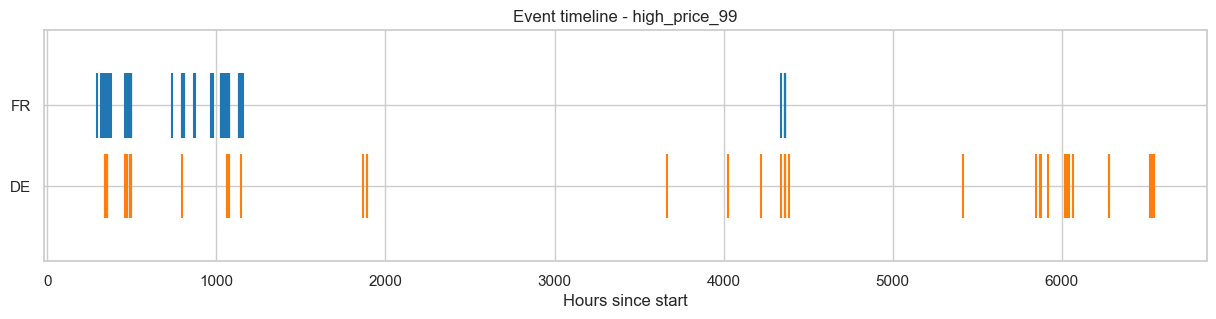

In [51]:
# Timeline / raster plot over the year
plt.figure(figsize=(15, 3))
plt.eventplot([fr_times, de_times], lineoffsets=[1, 0], linelengths=0.8, colors=["tab:blue", "tab:orange"])
plt.yticks([0, 1], ["DE", "FR"])
plt.xlabel("Hours since start")
plt.title(f"Event timeline - {selected_event}")
plt.show()

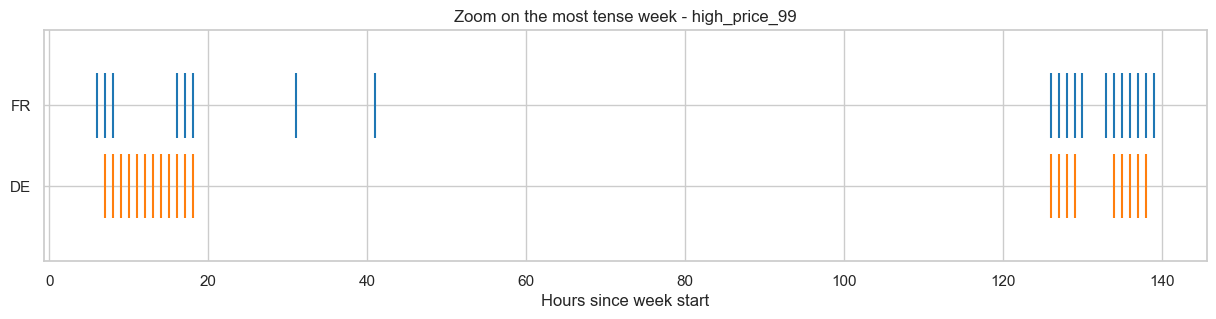

Zoom week: 2025-01-15 00:00:00+00:00 to 2025-01-21 00:00:00+00:00


In [52]:
# Zoom on most tense week from 7-day rolling sum of events
tmp = hawkes_df.set_index("datetime_utc")[["event_fr", "event_de"]].resample("D").sum()
tmp["total"] = tmp["event_fr"] + tmp["event_de"]
rolling7 = tmp["total"].rolling(7, min_periods=3).sum()

zoom_end = rolling7.idxmax()
zoom_start = zoom_end - pd.Timedelta(days=6)

zoom_df = hawkes_df[(hawkes_df["datetime_utc"] >= zoom_start) & (hawkes_df["datetime_utc"] <= zoom_end)].copy()
zoom_origin = zoom_start

fr_zoom = ((zoom_df.loc[zoom_df["event_fr"] == 1, "datetime_utc"] - zoom_origin).dt.total_seconds() / 3600.0).to_numpy()
de_zoom = ((zoom_df.loc[zoom_df["event_de"] == 1, "datetime_utc"] - zoom_origin).dt.total_seconds() / 3600.0).to_numpy()

plt.figure(figsize=(15, 3))
plt.eventplot([fr_zoom, de_zoom], lineoffsets=[1, 0], linelengths=0.8, colors=["tab:blue", "tab:orange"])
plt.yticks([0, 1], ["DE", "FR"])
plt.xlabel("Hours since week start")
plt.title(f"Zoom on the most tense week - {selected_event}")
plt.show()

print("Zoom week:", zoom_start, "to", zoom_end)


In [53]:
# Univariate exponential Hawkes MLE lambda(t) = mu + alpha * sum_{t_i < t} exp(-beta * (t - t_i)), branching alpha / beta
PENALTY = 1e12

def safe_positive_exp_sum(target_times, source_times, beta):
    """
    For each target time t, compute sum_j exp(-beta * (t - s_j)) 1_{s_j < t}
    in a numerically safe way.
    """
    target_times = np.asarray(target_times, dtype=float)
    source_times = np.asarray(source_times, dtype=float)

    if len(target_times) == 0:
        return np.array([], dtype=float)
    if len(source_times) == 0:
        return np.zeros(len(target_times), dtype=float)

    diff = target_times[:, None] - source_times[None, :]
    pos_diff = np.where(diff > 0, diff, np.inf)
    return np.exp(-beta * pos_diff).sum(axis=1)

def hawkes_univariate_nll(log_params, times, T):
    mu, alpha, beta = np.exp(log_params)

    if mu <= 0 or alpha < 0 or beta <= 0:
        return PENALTY

    branching = alpha / beta
    if branching >= 0.999:
        return PENALTY + 1e6 * (branching - 0.999) ** 2

    times = np.asarray(times, dtype=float)
    if len(times) == 0:
        return mu * T

    trigger_sum = safe_positive_exp_sum(times, times, beta)
    lam = mu + alpha * trigger_sum

    if np.any(~np.isfinite(lam)) or np.any(lam <= 0):
        return PENALTY

    integral = mu * T + (alpha / beta) * np.sum(1 - np.exp(-beta * (T - times)))
    ll = np.sum(np.log(lam)) - integral

    if not np.isfinite(ll):
        return PENALTY

    return -ll

def fit_univariate_hawkes(times, T):
    times = np.asarray(times, dtype=float)
    base_rate = max(len(times) / T, 1e-6)

    x0 = np.log([
        max(0.8 * base_rate, 1e-4),  # mu
        0.05,                        # alpha
        1.0                          # beta
    ])

    bounds = [
        (np.log(1e-6), np.log(5.0)),    # mu
        (np.log(1e-6), np.log(20.0)),   # alpha
        (np.log(1e-3), np.log(100.0))   # beta
    ]

    res = minimize(
        hawkes_univariate_nll,
        x0=x0,
        args=(times, T),
        method="L-BFGS-B",
        bounds=bounds
    )

    mu, alpha, beta = np.exp(res.x)
    branching = alpha / beta
    ll = -res.fun

    if branching < 1:
        lambda_bar = mu / (1 - branching)
        endogenous_share = branching
        exogenous_share = 1 - branching
    else:
        lambda_bar = np.nan
        endogenous_share = np.nan
        exogenous_share = np.nan

    return {
        "mu": mu,
        "alpha": alpha,
        "beta": beta,
        "branching_ratio": branching,
        "lambda_bar": lambda_bar,
        "endogenous_share": endogenous_share,
        "exogenous_share": exogenous_share,
        "loglik": ll,
        "success": bool(res.success and np.isfinite(ll) and ll < PENALTY / 10),
        "opt_result": res
    }

def hawkes_univariate_intensity(grid, times, mu, alpha, beta):
    grid = np.asarray(grid, dtype=float)
    times = np.asarray(times, dtype=float)
    trigger_sum = safe_positive_exp_sum(grid, times, beta)
    lam = mu + alpha * trigger_sum
    lam[~np.isfinite(lam)] = np.nan
    return lam


fit_fr_uni = fit_univariate_hawkes(fr_times, T)
fit_de_uni = fit_univariate_hawkes(de_times, T)

pd.DataFrame([fit_fr_uni, fit_de_uni], index=["FR", "DE"])[
    ["mu", "alpha", "beta", "branching_ratio", "lambda_bar", "endogenous_share", "exogenous_share", "loglik", "success"]
].round(4)


,mu,alpha,beta,branching_ratio,lambda_bar,endogenous_share,exogenous_share,loglik,success
FR,0.0014,0.1001,0.1193,0.8391,0.0090,0.8391,0.1609,-221.1900,True
DE,0.0031,0.1242,0.1864,0.6663,0.0093,0.6663,0.3337,-250.7652,True


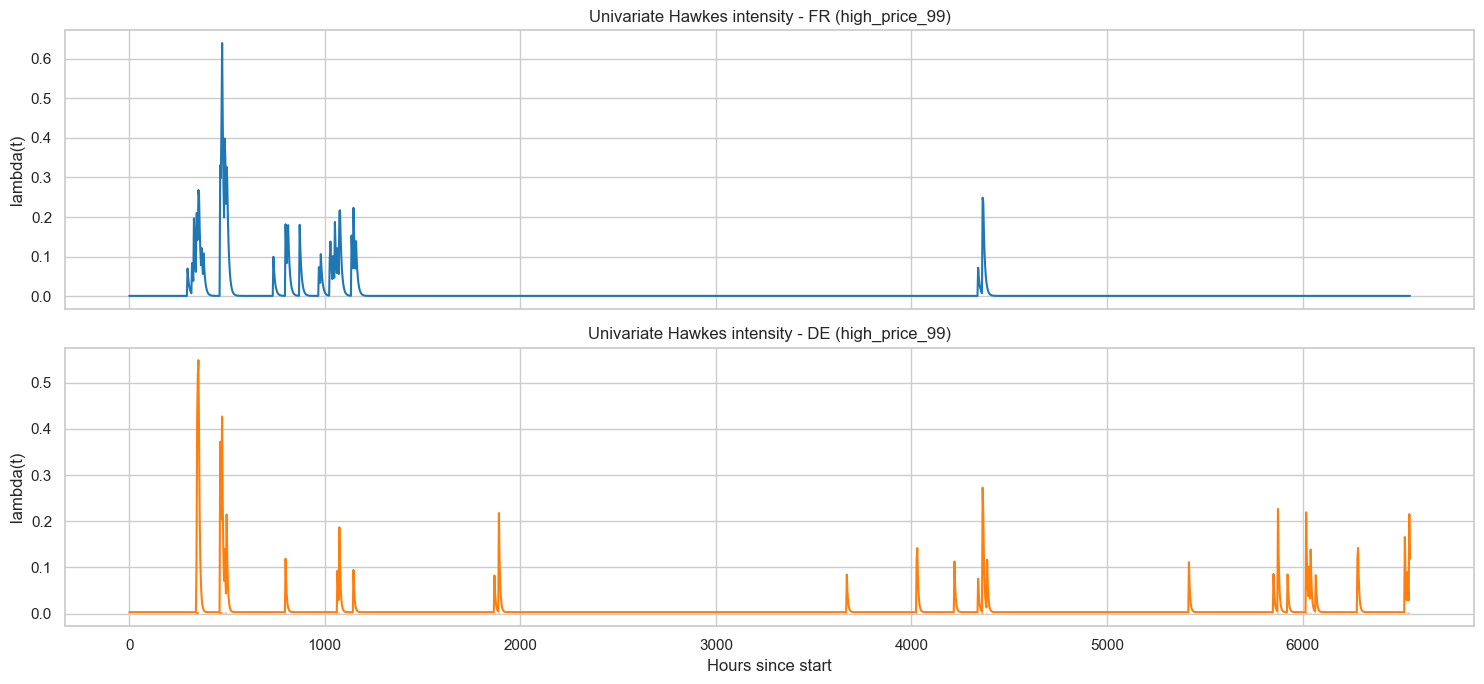

In [54]:
# Univariate intensity plots
grid_full = np.linspace(0, T, 2000)

lam_fr = hawkes_univariate_intensity(grid_full, fr_times, fit_fr_uni["mu"], fit_fr_uni["alpha"], fit_fr_uni["beta"])
lam_de = hawkes_univariate_intensity(grid_full, de_times, fit_de_uni["mu"], fit_de_uni["alpha"], fit_de_uni["beta"])

fig, axes = plt.subplots(2, 1, figsize=(15, 7), sharex=True)

axes[0].plot(grid_full, lam_fr, color="tab:blue")
axes[0].vlines(fr_times, ymin=0, ymax=np.quantile(lam_fr, 0.25), color="tab:blue", alpha=0.2)
axes[0].set_title(f"Univariate Hawkes intensity - FR ({selected_event})")
axes[0].set_ylabel("lambda(t)")

axes[1].plot(grid_full, lam_de, color="tab:orange")
axes[1].vlines(de_times, ymin=0, ymax=np.quantile(lam_de, 0.25), color="tab:orange", alpha=0.2)
axes[1].set_title(f"Univariate Hawkes intensity - DE ({selected_event})")
axes[1].set_ylabel("lambda(t)")
axes[1].set_xlabel("Hours since start")

plt.tight_layout()
plt.show()

In [55]:
# Bivariate exponential hawkes lambda_i(t) = mu_i + sum_j alpha_ij * sum_{t_k^j < t} exp(-beta_ij * (t - t_k^j))
def unpack_bivariate_params(log_params):
    p = np.exp(log_params)
    mu = np.array([p[0], p[1]])
    alpha = np.array([[p[2], p[3]],
                      [p[4], p[5]]])
    beta = np.array([[p[6], p[7]],
                     [p[8], p[9]]])
    return mu, alpha, beta

def hawkes_bivariate_nll(log_params, times_list, T):
    mu, alpha, beta = unpack_bivariate_params(log_params)

    if np.any(mu <= 0) or np.any(alpha < 0) or np.any(beta <= 0):
        return PENALTY

    G = alpha / beta
    spectral_radius = np.max(np.abs(np.linalg.eigvals(G)))
    if spectral_radius >= 0.999:
        return PENALTY + 1e6 * (spectral_radius - 0.999) ** 2

    ll = 0.0

    for i in range(2):
        ti = np.asarray(times_list[i], dtype=float)
        lam = np.full(len(ti), mu[i], dtype=float)

        for j in range(2):
            tj = np.asarray(times_list[j], dtype=float)
            if len(ti) == 0 or len(tj) == 0:
                continue
            lam += alpha[i, j] * safe_positive_exp_sum(ti, tj, beta[i, j])

        if np.any(~np.isfinite(lam)) or np.any(lam <= 0):
            return PENALTY

        ll += np.sum(np.log(lam))
        ll -= mu[i] * T

        for j in range(2):
            tj = np.asarray(times_list[j], dtype=float)
            if len(tj) == 0:
                continue
            ll -= (alpha[i, j] / beta[i, j]) * np.sum(1 - np.exp(-beta[i, j] * (T - tj)))

    if not np.isfinite(ll):
        return PENALTY

    return -ll

def fit_bivariate_hawkes(times_list, T):
    rate_1 = max(len(times_list[0]) / T, 1e-6)
    rate_2 = max(len(times_list[1]) / T, 1e-6)

    x0 = np.log([
        max(0.8 * rate_1, 1e-4), max(0.8 * rate_2, 1e-4),  # mu
        0.05, 0.02,                                        # alpha row 1
        0.02, 0.05,                                        # alpha row 2
        1.0, 1.0, 1.0, 1.0                                 # beta
    ])

    bounds = [
        (np.log(1e-6), np.log(5.0)),   # mu1
        (np.log(1e-6), np.log(5.0)),   # mu2
        (np.log(1e-6), np.log(20.0)),  # a11
        (np.log(1e-6), np.log(20.0)),  # a12
        (np.log(1e-6), np.log(20.0)),  # a21
        (np.log(1e-6), np.log(20.0)),  # a22
        (np.log(1e-3), np.log(100.0)), # b11
        (np.log(1e-3), np.log(100.0)), # b12
        (np.log(1e-3), np.log(100.0)), # b21
        (np.log(1e-3), np.log(100.0)), # b22
    ]

    res = minimize(
        hawkes_bivariate_nll,
        x0=x0,
        args=(times_list, T),
        method="L-BFGS-B",
        bounds=bounds,
        options={"maxiter": 500}
    )

    mu, alpha, beta = unpack_bivariate_params(res.x)
    G = alpha / beta
    spectral_radius = np.max(np.abs(np.linalg.eigvals(G)))
    ll = -res.fun

    if spectral_radius < 1:
        lambda_bar = np.linalg.solve(np.eye(2) - G, mu)
        endogenous_share = 1 - mu / lambda_bar
    else:
        lambda_bar = np.array([np.nan, np.nan])
        endogenous_share = np.array([np.nan, np.nan])

    return {
        "mu": mu,
        "alpha": alpha,
        "beta": beta,
        "G": G,
        "spectral_radius": spectral_radius,
        "lambda_bar": lambda_bar,
        "endogenous_share": endogenous_share,
        "loglik": ll,
        "success": bool(res.success and np.isfinite(ll) and ll < PENALTY / 10),
        "opt_result": res
    }

def hawkes_bivariate_intensity(grid, times_list, mu, alpha, beta):
    grid = np.asarray(grid, dtype=float)
    out = np.zeros((2, len(grid)), dtype=float)

    for i in range(2):
        out[i] = mu[i]
        for j in range(2):
            out[i] += alpha[i, j] * safe_positive_exp_sum(grid, times_list[j], beta[i, j])

    out[~np.isfinite(out)] = np.nan
    return out

fit_bi = fit_bivariate_hawkes([fr_times, de_times], T)
fit_bi


{'mu': array([0.00144231, 0.00276983]),
 'alpha': array([[0.09717745, 0.00851364],
        [0.0171493 , 0.1564235 ]]),
 'beta': array([[0.11748524, 0.66530881],
        [0.09862323, 0.29883582]]),
 'G': array([[0.827146  , 0.01279653],
        [0.17388706, 0.52344294]]),
 'spectral_radius': np.float64(0.8343040192724802),
 'lambda_bar': array([0.00901798, 0.00910266]),
 'endogenous_share': array([0.84006269, 0.69571231]),
 'loglik': np.float64(-467.0364060710263),
 'success': True,
 'opt_result':   message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
   success: True
    status: 0
       fun: 467.0364060710263
         x: [-6.542e+00 -5.889e+00 -2.331e+00 -4.766e+00 -4.066e+00
             -1.855e+00 -2.141e+00 -4.075e-01 -2.316e+00 -1.208e+00]
       nit: 44
       jac: [-4.547e-05  4.434e-04  1.012e-03  0.000e+00  1.933e-04
              9.607e-04 -1.131e-03  1.705e-04 -2.501e-04 -1.086e-03]
      nfev: 638
      njev: 58
  hess_inv: <10x10 LbfgsInvHessProduct with dtype=flo

In [56]:
# Bivariate summary tables
mu = fit_bi["mu"]
alpha = fit_bi["alpha"]
beta = fit_bi["beta"]
G = fit_bi["G"]

hawkes_param_table = pd.DataFrame({
    "mu": mu,
    "lambda_bar": fit_bi["lambda_bar"],
    "endogenous_share": fit_bi["endogenous_share"]
}, index=["FR", "DE"])

hawkes_kernel_table = pd.DataFrame(G, index=["FR<-FR", "DE<-FR"], columns=["from FR", "from DE"])
# Note: rows here are not labeled ideally for reading, so we also make a clean table below
hawkes_kernel_table_clean = pd.DataFrame(
    G,
    index=["FR target", "DE target"],
    columns=["FR source", "DE source"]
)

print("Log-likelihood:", fit_bi["loglik"])
print("Spectral radius:", fit_bi["spectral_radius"])
display(hawkes_param_table.round(4))
display(hawkes_kernel_table_clean.round(4))


Log-likelihood: -467.0364060710263
Spectral radius: 0.8343040192724802


,mu,lambda_bar,endogenous_share
FR,0.0014,0.0090,0.8401
DE,0.0028,0.0091,0.6957


,FR source,DE source
FR target,0.8271,0.0128
DE target,0.1739,0.5234


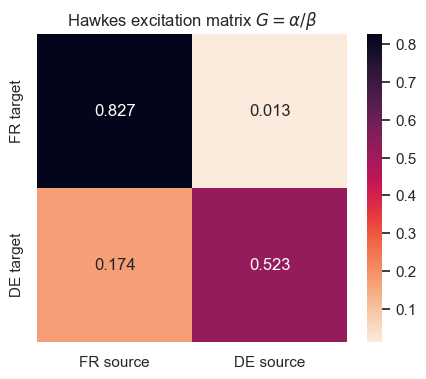

In [57]:
# Excitation matrix heatmap G_ij = alpha_ij / beta_ij
plt.figure(figsize=(5, 4))
sns.heatmap(
    fit_bi["G"],
    annot=True,
    fmt=".3f",
    cmap="rocket_r",
    xticklabels=["FR source", "DE source"],
    yticklabels=["FR target", "DE target"]
)
plt.title("Hawkes excitation matrix $G = \\alpha / \\beta$")
plt.show()

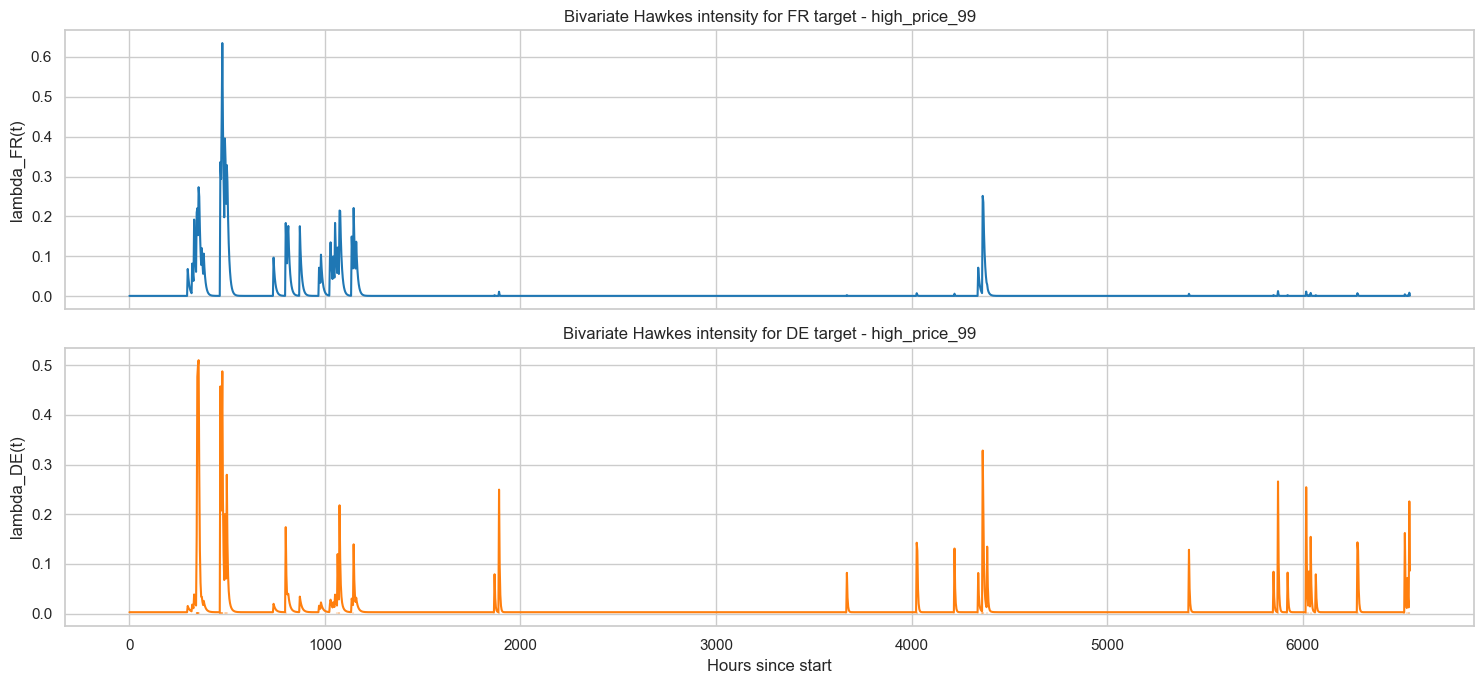

In [58]:
# Bivariate intensity over the full sample
grid_full = np.linspace(0, T, 2000)
lam_bi = hawkes_bivariate_intensity(grid_full, [fr_times, de_times], fit_bi["mu"], fit_bi["alpha"], fit_bi["beta"])

fig, axes = plt.subplots(2, 1, figsize=(15, 7), sharex=True)

axes[0].plot(grid_full, lam_bi[0], color="tab:blue")
axes[0].vlines(fr_times, ymin=0, ymax=np.quantile(lam_bi[0], 0.25), color="tab:blue", alpha=0.2)
axes[0].set_title(f"Bivariate Hawkes intensity for FR target - {selected_event}")
axes[0].set_ylabel("lambda_FR(t)")

axes[1].plot(grid_full, lam_bi[1], color="tab:orange")
axes[1].vlines(de_times, ymin=0, ymax=np.quantile(lam_bi[1], 0.25), color="tab:orange", alpha=0.2)
axes[1].set_title(f"Bivariate Hawkes intensity for DE target - {selected_event}")
axes[1].set_ylabel("lambda_DE(t)")
axes[1].set_xlabel("Hours since start")

plt.tight_layout()
plt.show()


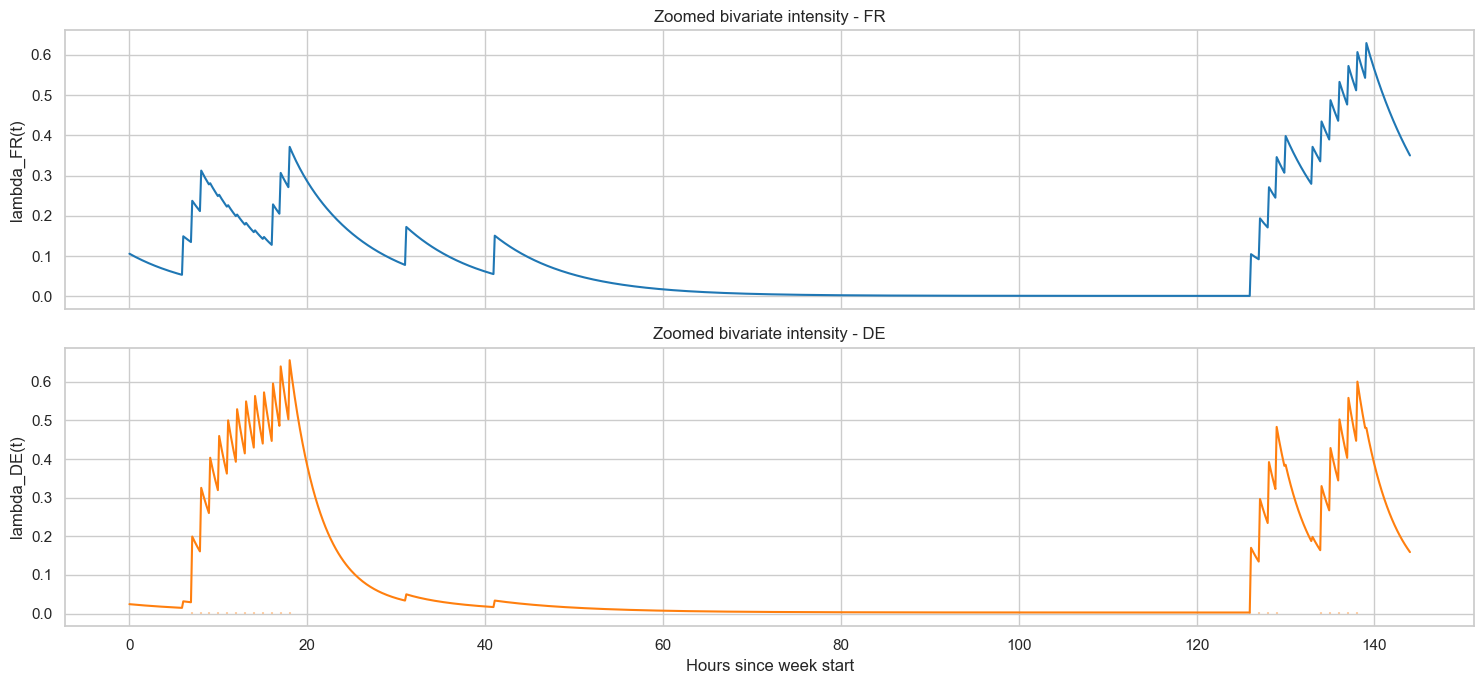

In [59]:
# Zoom intensity on the most tense week
zoom_start_h = (zoom_start - origin).total_seconds() / 3600.0
zoom_end_h = (zoom_end - origin).total_seconds() / 3600.0
grid_zoom = np.linspace(zoom_start_h, zoom_end_h, 1000)

lam_zoom = hawkes_bivariate_intensity(grid_zoom, [fr_times, de_times], fit_bi["mu"], fit_bi["alpha"], fit_bi["beta"])

fr_zoom_abs = fr_times[(fr_times >= zoom_start_h) & (fr_times <= zoom_end_h)]
de_zoom_abs = de_times[(de_times >= zoom_start_h) & (de_times <= zoom_end_h)]

fig, axes = plt.subplots(2, 1, figsize=(15, 7), sharex=True)

axes[0].plot(grid_zoom - zoom_start_h, lam_zoom[0], color="tab:blue")
axes[0].vlines(fr_zoom_abs - zoom_start_h, ymin=0, ymax=np.quantile(lam_zoom[0], 0.25), color="tab:blue", alpha=0.35)
axes[0].set_title("Zoomed bivariate intensity - FR")
axes[0].set_ylabel("lambda_FR(t)")

axes[1].plot(grid_zoom - zoom_start_h, lam_zoom[1], color="tab:orange")
axes[1].vlines(de_zoom_abs - zoom_start_h, ymin=0, ymax=np.quantile(lam_zoom[1], 0.25), color="tab:orange", alpha=0.35)
axes[1].set_title("Zoomed bivariate intensity - DE")
axes[1].set_ylabel("lambda_DE(t)")
axes[1].set_xlabel("Hours since week start")

plt.tight_layout()
plt.show()


In [60]:
# Export tables
event_summary.to_csv("hawkes_event_summary.csv", index=False)
hawkes_param_table.to_csv("hawkes_bivariate_node_summary.csv")
hawkes_kernel_table_clean.to_csv("hawkes_bivariate_excitation_matrix.csv")
hawkes_df.to_csv("hawkes_analysis_frame_fr_de.csv", index=False)


### Analyse des résultats

Nous considérons ici les événements correspondant aux prix très élevés, définis comme les observations situées au-dessus du quantile empirique à 99 %. Sur l’ensemble de la fenêtre d’observation, cela représente 59 événements en France et 59 en Allemagne, soit des événements rares, mais suffisamment nombreux pour permettre une estimation ponctuelle. Ce choix permet d’étudier spécifiquement la dynamique temporelle des épisodes de tension extrême sur le marché électrique, en se concentrant non plus sur les prix négatifs, mais sur les pics de prix les plus élevés.

Les estimations univariées mettent en évidence un fort phénomène d’auto-excitation dans les deux pays. En France, l’intensité de base est très faible ($\mu \approx 0.0014$), alors que le branching ratio vaut environ 0.8391. En Allemagne, on obtient $\mu \approx 0.0031$ et un branching ratio de 0.6663. Ces résultats indiquent qu’une fois qu’un épisode de prix très élevé apparaît, il tend à être suivi d’autres épisodes proches dans le temps, en particulier en France où la composante endogène est encore plus marquée.

La décomposition exogène/endogène confirme cette lecture. En France, environ 84 % de l’activité extrême est attribuable à la dynamique auto-excitée, contre seulement 16 % à la composante exogène. En Allemagne, la part endogène reste élevée, autour de 67 %. Les pics de prix élevés ne se comportent donc pas comme des chocs isolés : ils tendent à se regrouper dans le temps, ce qui est précisément le type de structure que le modèle de Hawkes cherche à capturer.

Le modèle bivarié confirme d’abord que la dynamique estimée reste dans une zone stable. Le rayon spectral de la matrice d’excitation vaut 0.8343, ce qui reste strictement inférieur à 1 ; le modèle est donc stationnaire au sens du cadre multivarié retenu. Les intensités moyennes de long terme sont très proches dans les deux pays, avec $\bar\lambda_{FR} \approx 0.0090$ et $\bar\lambda_{DE} \approx 0.0091$, ce qui reflète la rareté globale des événements étudiés.

La matrice d’excitation estimée montre ensuite une structure asymétrique intéressante. Les effets diagonaux sont importants : $G_{FR,FR} \approx 0.8271$ et $G_{DE,DE} \approx 0.5234$. Cela signifie qu’un épisode de prix très élevé a une forte capacité à engendrer de nouveaux épisodes du même type dans le même pays, surtout en France. L’auto-excitation des pics de prix est donc particulièrement forte du côté français.

Les effets croisés sont, en revanche, plus modestes et surtout dissymétriques. L’effet de la France vers l’Allemagne est plus important ($G_{DE,FR} \approx 0.1739$) que l’effet de l’Allemagne vers la France ($G_{FR,DE} \approx 0.0128$). Cela suggère que, pour les événements les plus extrêmes, les tensions sur le marché français semblent davantage se transmettre au marché allemand que l’inverse. Cette asymétrie diffère de celle observée sur les prix négatifs, ce qui indique que la dynamique de propagation dépend fortement de la nature de l’événement considéré.

Enfin, les parts endogènes issues du modèle bivarié restent élevées : environ 84.0 % pour la France et 69.6 % pour l’Allemagne. Cela signifie qu’une grande partie des épisodes de prix très élevés provient de mécanismes internes de clustering et de propagation, plus que de simples chocs de fond indépendants. Le modèle met donc en évidence une contagion temporelle nette, ainsi qu’une certaine transmission transfrontalière, surtout depuis la France vers l’Allemagne pour cette définition particulière des extrêmes.

Au total, cette analyse montre que les épisodes de prix extrêmement élevés en 2025 sont rares mais fortement structurés dans le temps. Ils présentent une auto-excitation marquée, particulièrement en France, et une excitation croisée asymétrique entre les deux marchés. Par comparaison avec l’analyse sur les prix négatifs, cela suggère que la dynamique des extrêmes dépend non seulement de leur intensité, mais aussi de leur signe : les épisodes de tension à la hausse et les épisodes de prix négatifs ne se propagent pas de la même manière dans le système franco-allemand.
